## Mixed-Effects Models: Study 1 & Study 2

This notebook combines analyses from both studies with reusable functions for:
- Data preprocessing
- Model fitting
- Figure generation (including multi-panel comparisons)

**Key Differences:**
- **Study 1:** 7 environments (53-92 dB), includes `condition` (sitting/standing)
- **Study 2:** 4 environments (60-87.5 dB), no condition variable (always sitting)

## 1. Setup

### 1.1 Load Packages

In [30]:
# Load required packages
suppressPackageStartupMessages({
  library(tidyverse)  # for data manipulation and visualization
  library(lme4)       # for mixed-effects models
  library(lmerTest)   # for p-values in lmer
  library(emmeans)    # for pairwise comparisons
  library(glmmTMB)    # for GLMMs
  library(DHARMa)     # for model diagnostics
  library(patchwork)  # for combining plots
})

# Source utility scripts
source("utils/r_utils.R")
source("utils/r_plotting_utils.R")

# Resize plots and suppress warnings for cleaner output
options(
  repr.plot.width  = 10,
  repr.plot.height = 5,
  repr.plot.res    = 150,
  warn = -1
)
emm_options(msg.interaction = FALSE)

### 1.2 Print Version Information

In [31]:
# Print package and R version info for manuscript

cat("\n===== VERSION INFORMATION =====\n")

cat("R version:\n")
cat(paste0(R.version$major, ".", R.version$minor, " (", R.version$year, ")\n\n"))

pkgs <- c("lmerTest", "glmmTMB", "emmeans")
for (pkg in pkgs) {
  if (requireNamespace(pkg, quietly = TRUE)) {
    cat(pkg, "version:", as.character(utils::packageVersion(pkg)), "\n")
  } else {
    cat(pkg, "is not installed.\n")
  }
}

cat("\n================================\n")



===== VERSION INFORMATION =====
R version:
4.5.1 (2025)

lmerTest version: 3.1.3 
glmmTMB version: 1.1.13 
emmeans version: 1.11.2.8 



### 1.3 Study Configuration

Define study-specific parameters (including conditions, SPL mappings, environment levels).

In [32]:
# --- Study 1 Configuration ---
study1_config <- list(
  study_id = "study1",
  dfa_file = "final datasets/study1/study1_dfa_models.csv",
  cc_file = "final datasets/study1/study1_cc_models.csv",
  environments = c("Library", "Living", "Cafe", "Train", "FoodCourt", "NoMusicParty", "MusicParty"),
  spl_map = c(
    Library      = 53.0,
    Living       = 63.3,
    Cafe         = 71.7,
    Train        = 77.1,
    FoodCourt    = 79.6,
    NoMusicParty = 85.0,
    MusicParty   = 92.0
  ),
  spl_range = c(50, 95),
  has_condition = TRUE,
  n_environments = 7
)

# --- Study 2 Configuration ---
study2_config <- list(
  study_id = "study2",
  dfa_file = "final datasets/study2/study2_dfa_models.csv",
  cc_file = "final datasets/study2/study2_cc_models.csv",
  environments = c("Office", "Cafe", "Food", "Party"),
  spl_map = c(
    Office = 60.0,
    Cafe   = 70.0,
    Food   = 80.0,
    Party  = 87.5
  ),
  spl_range = c(55, 90),
  has_condition = FALSE,
  n_environments = 4
)

# Print configurations
cat("Study 1:", study1_config$n_environments, "environments, SPL range:", 
    study1_config$spl_range[1], "-", study1_config$spl_range[2], "dB\n")
cat("Study 2:", study2_config$n_environments, "environments, SPL range:", 
    study2_config$spl_range[1], "-", study2_config$spl_range[2], "dB\n")

Study 1: 7 environments, SPL range: 50 - 95 dB
Study 2: 4 environments, SPL range: 55 - 90 dB


### 1.4 Load Data for Both Studies

In [33]:
# Load individual (DFA/RMS) data
dfa_df1 <- load_individual_data(study1_config)
dfa_df2 <- load_individual_data(study2_config)

# Create copies for RMS analyses
rms_df1 <- dfa_df1
rms_df2 <- dfa_df2

# Load dyadic (cross-correlation) data
cm_df1 <- load_dyadic_data(study1_config)
cm_df2 <- load_dyadic_data(study2_config)

# Quick data check
cat("Study 1 - DFA data:", nrow(dfa_df1), "rows\n")
cat("Study 2 - DFA data:", nrow(dfa_df2), "rows\n")
cat("Study 1 - CC data:", nrow(cm_df1), "rows\n")
cat("Study 2 - CC data:", nrow(cm_df2), "rows\n")

Study 1 - DFA data: 616 rows
Study 2 - DFA data: 447 rows
Study 1 - CC data: 1232 rows
Study 2 - CC data: 1100 rows


## 2. Alpha Analysis

### 2.1 Study 1: Alpha ~ Condition × Environment

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: mean_alpha ~ condition * environment_cent + (1 + condition +  
    environment_cent | pair)
   Data: dfa_df1

REML criterion at convergence: -962.5

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.8347 -0.5966 -0.0140  0.6182  3.5570 

Random effects:
 Groups   Name              Variance  Std.Dev. Corr       
 pair     (Intercept)       4.162e-03 0.064517            
          conditionstanding 5.952e-03 0.077152 -0.67      
          environment_cent  2.262e-06 0.001504  0.29 -0.37
 Residual                   9.947e-03 0.099733            
Number of obs: 616, groups:  pair, 22

Fixed effects:
                                    Estimate Std. Error        df t value
(Intercept)                        1.040e+00  1.488e-02 2.100e+01  69.888
conditionstanding                  1.003e-04  1.831e-02 2.100e+01   0.005
environment_cent                   2.643e-03  5.650e-04 4.757e+01  

,condition,environment_cent.trend,SE,df,lower.CL,upper.CL,t.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,sitting,0.002642922,0.0005649672,47.5755,0.001506717,0.003779126,4.678009,2.426401e-05
2,standing,0.004038282,0.0005649672,47.5755,0.002902077,0.005174486,7.147816,4.575039e-09


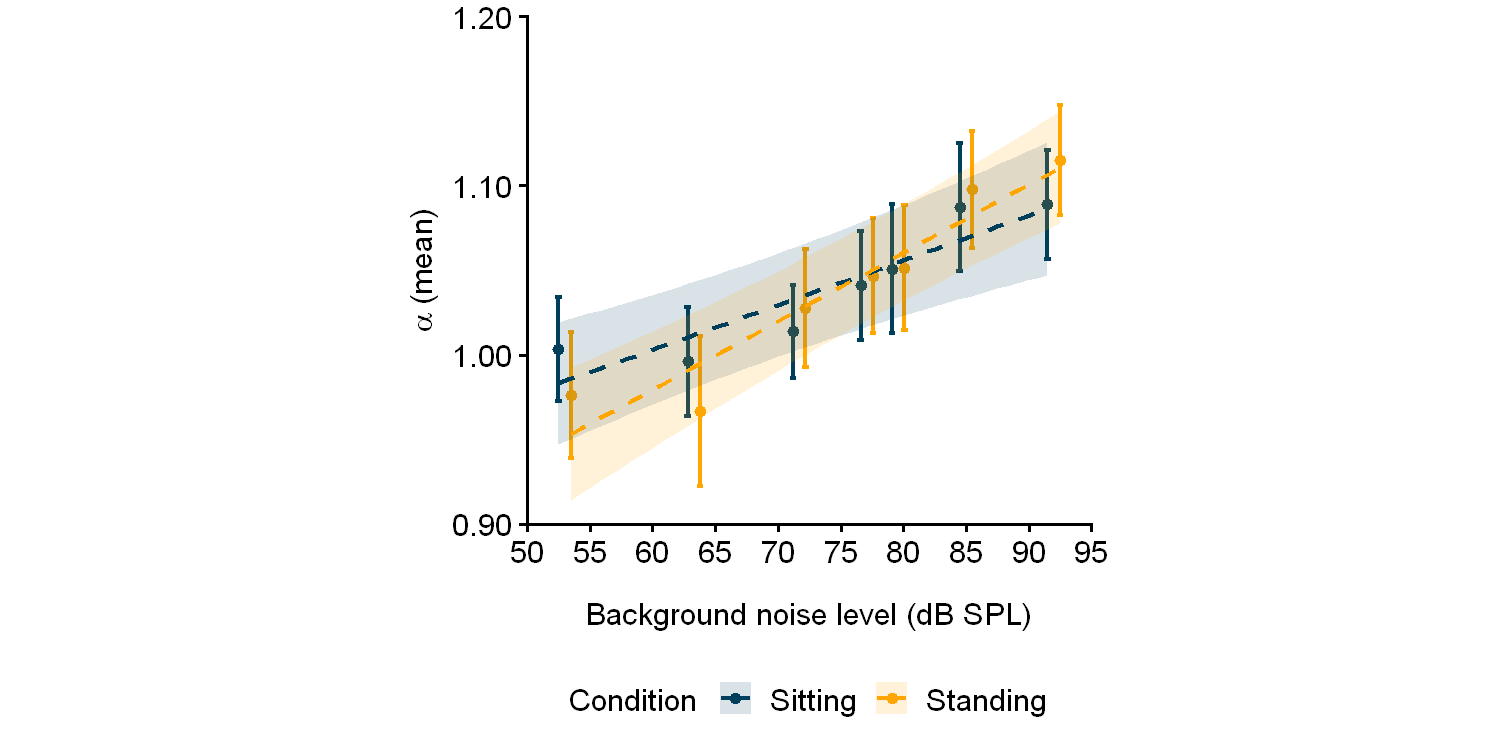

In [34]:
# Fit model
m1_alpha <- lmer(
  mean_alpha ~ condition * environment_cent + (1 + condition + environment_cent | pair), 
  data = dfa_df1
)
summary(m1_alpha)

# Estimated slopes
slopes_s1 <- emtrends(m1_alpha, ~ condition, var = "environment_cent")
summary(slopes_s1, infer = TRUE)

# Estimated marginal means
emm_s1_alpha <- as.data.frame(emmeans(
  m1_alpha, ~ condition * environment_cent,
  at = list(environment_cent = seq(
    min(dfa_df1$environment_num, na.rm = TRUE) - mean(dfa_df1$environment_num, na.rm = TRUE),
    max(dfa_df1$environment_num, na.rm = TRUE) - mean(dfa_df1$environment_num, na.rm = TRUE),
    length.out = 50
  )),
  infer = c(TRUE, TRUE)
))

# Map to SPL scale
emm_s1_alpha <- map_emm_to_spl(emm_s1_alpha, study1_config, dfa_df1)

# Recode condition labels for plotting
emm_s1_alpha <- emm_s1_alpha %>%
  mutate(condition = recode(as.character(condition),
                            "sitting" = "Sitting",
                            "standing" = "Standing") %>%
           factor(levels = c("Sitting", "Standing")))

# Prepare summary data
summary_s1_alpha <- summarize_by_environment(dfa_df1, study1_config, "mean_alpha")

# Recode condition for plotting
summary_s1_alpha <- summary_s1_alpha %>%
  mutate(condition = recode(as.character(condition),
                            "sitting" = "Sitting",
                            "standing" = "Standing") %>%
           factor(levels = c("Sitting", "Standing")))

# Create plot with explicit y-axis limits and breaks
p1_alpha <- plot_continuous_by_spl(
  summary_df = summary_s1_alpha,
  emm_df = emm_s1_alpha,
  config = study1_config,
  ylabel = expression(alpha~"(mean)"),
  colors = c("Sitting" = "#003f5c", "Standing" = "#ffa600"),
  ylim = c(0.9, 1.2),
  ybreaks = seq(0.9, 1.2, by = 0.1)
)

print(p1_alpha)

### 2.2 Study 2: Alpha ~ Environment

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: mean_alpha ~ environment_cent + (1 | pair)
   Data: dfa_df2

REML criterion at convergence: -1368.2

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.4207 -0.6596 -0.0402  0.6312  4.0627 

Random effects:
 Groups   Name        Variance  Std.Dev.
 pair     (Intercept) 0.0009048 0.03008 
 Residual             0.0020928 0.04575 
Number of obs: 440, groups:  pair, 47

Fixed effects:
                  Estimate Std. Error        df t value Pr(>|t|)    
(Intercept)      9.680e-01  4.914e-03 4.507e+01 196.978   <2e-16 ***
environment_cent 1.869e-03  2.024e-04 3.942e+02   9.233   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Correlation of Fixed Effects:
            (Intr)
envrnmnt_cn 0.003 

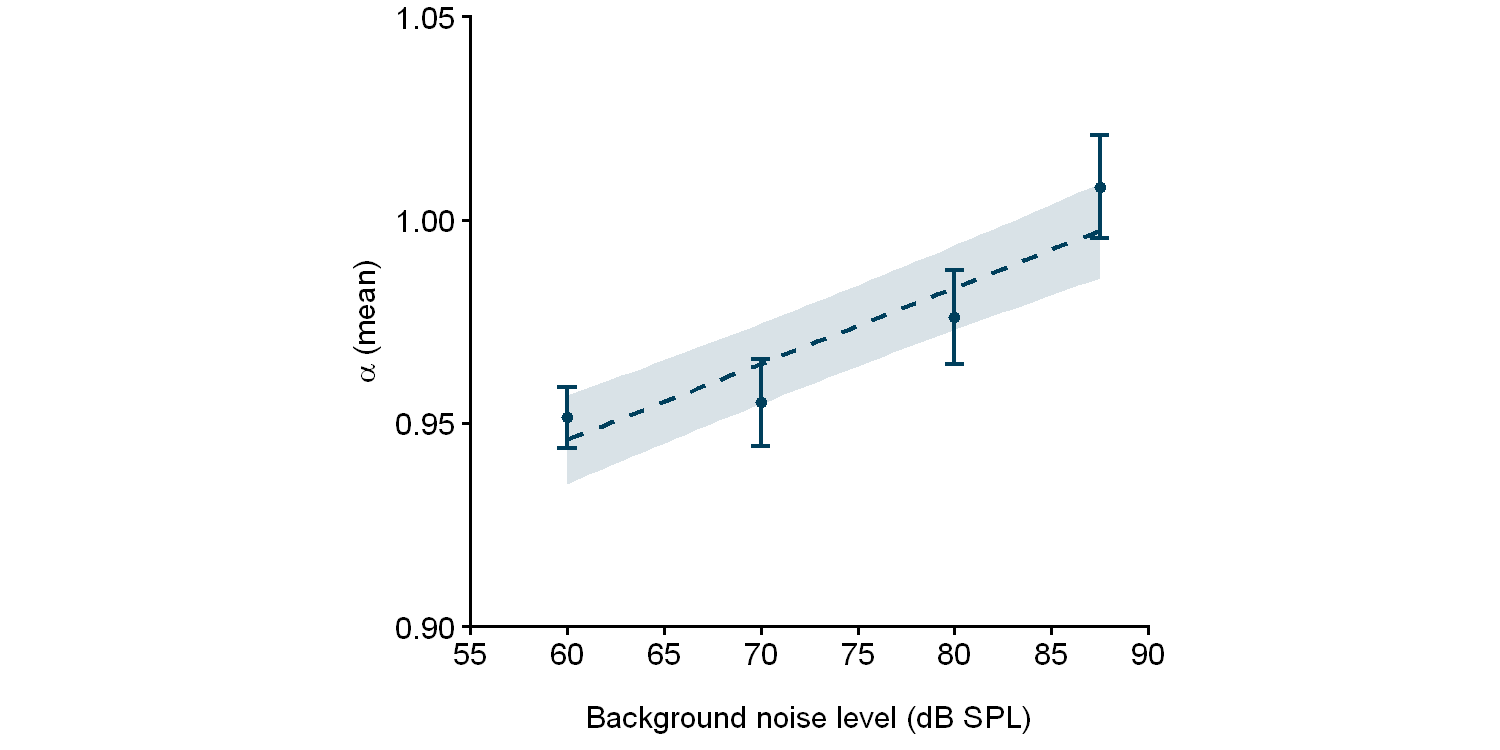

In [35]:
# Fit model
m2_alpha <- lmer(mean_alpha ~ environment_cent + (1 | pair), data = dfa_df2)
summary(m2_alpha)

# Estimated marginal means
emm_s2_alpha <- as.data.frame(emmeans(
  m2_alpha, ~ environment_cent,
  at = list(environment_cent = seq(
    min(dfa_df2$environment_num, na.rm = TRUE) - mean(dfa_df2$environment_num, na.rm = TRUE),
    max(dfa_df2$environment_num, na.rm = TRUE) - mean(dfa_df2$environment_num, na.rm = TRUE),
    length.out = 50
  )),
  infer = c(TRUE, TRUE)
))

# Map to SPL scale
emm_s2_alpha <- map_emm_to_spl(emm_s2_alpha, study2_config, dfa_df2)

# Prepare summary data
summary_s2_alpha <- summarize_by_environment(dfa_df2, study2_config, "mean_alpha")

# Create plot with explicit y-axis limits and breaks
p2_alpha <- plot_continuous_by_spl(
  summary_df = summary_s2_alpha,
  emm_df = emm_s2_alpha,
  config = study2_config,
  ylabel = expression(alpha~"(mean)"),
  colors = c("#003f5c", "#ffa600"),
  ylim = c(0.9, 1.05),
  ybreaks = seq(0.9, 1.05, by = 0.05)
)

print(p2_alpha)

### 2.5 Combined Multi-Panel Figure: Alpha Comparison

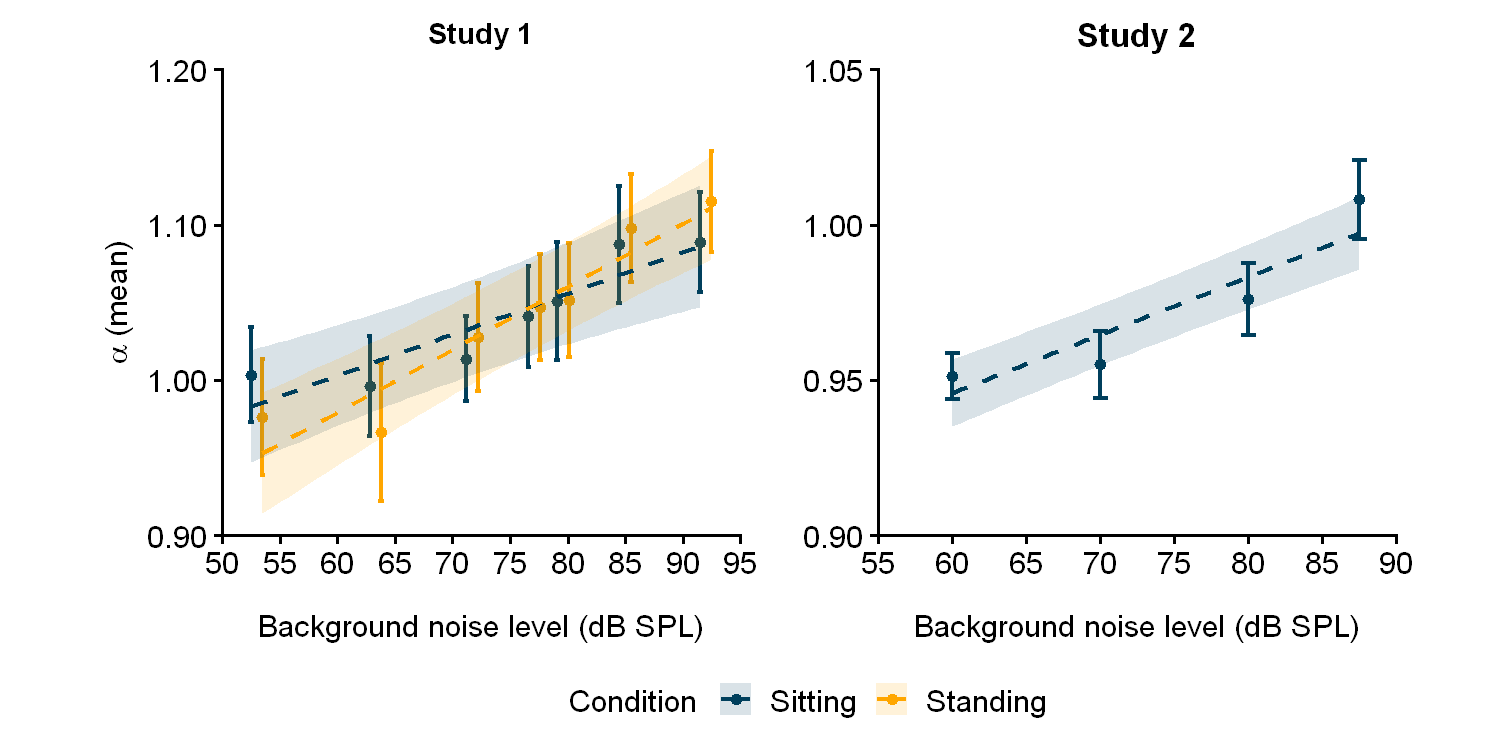

In [36]:
# Combine plots using helper function
p_alpha_combined <- combine_study_plots(
  plot1 = p1_alpha,
  plot2 = p2_alpha,
  filename = "figures/manuscript/combined_alpha_by_noise.png"
)

print(p_alpha_combined)

## 3. RMS Analysis

### 3.1 Study 1: RMS ~ Condition × Environment

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: mean_rms_log ~ condition * environment_cent + (1 + condition |  
    pair)
   Data: rms_df1

REML criterion at convergence: 515.4

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.0867 -0.6725  0.0474  0.6449  3.3017 

Random effects:
 Groups   Name              Variance Std.Dev. Corr 
 pair     (Intercept)       0.07507  0.2740        
          conditionstanding 0.08959  0.2993   -0.69
 Residual                   0.11117  0.3334        
Number of obs: 616, groups:  pair, 22

Fixed effects:
                                     Estimate Std. Error         df t value
(Intercept)                         -2.623734   0.061426  20.999959 -42.714
conditionstanding                    0.749556   0.069241  21.000172  10.825
environment_cent                     0.008660   0.001555 569.999954   5.569
conditionstanding:environment_cent  -0.007922   0.002199 569.999954  -3.602
              

,condition,environment_cent.trend,SE,df,lower.CL,upper.CL,t.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,sitting,0.0086596411,0.001555101,570,0.005605213,0.011714069,5.5685383,3.961513e-08
2,standing,0.0007378201,0.001555101,570,-0.002316608,0.003792248,0.4744515,6.353597e-01


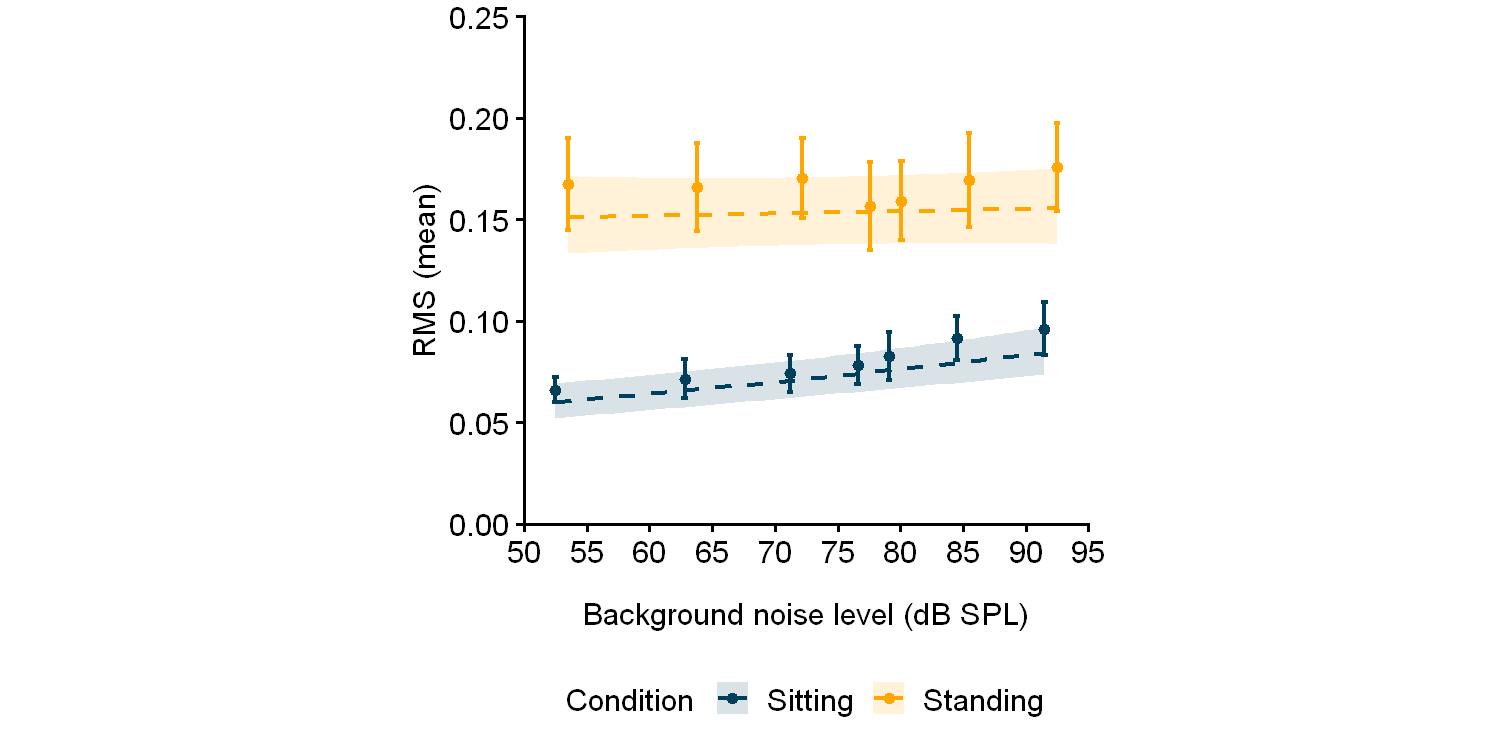

In [37]:
# Fit model (log-transformed RMS)
m1_rms <- lmer(
  mean_rms_log ~ condition * environment_cent + (1 + condition | pair),
  data = rms_df1
)
summary(m1_rms)

# Estimated slopes
slopes_rms_s1 <- emtrends(m1_rms, ~ condition, var = "environment_cent")
summary(slopes_rms_s1, infer = TRUE)

# Estimated marginal means (on log scale)
emm_s1_rms <- as.data.frame(emmeans(
  m1_rms, ~ condition * environment_cent,
  at = list(environment_cent = seq(
    min(rms_df1$environment_num, na.rm = TRUE) - mean(rms_df1$environment_num, na.rm = TRUE),
    max(rms_df1$environment_num, na.rm = TRUE) - mean(rms_df1$environment_num, na.rm = TRUE),
    length.out = 50
  )),
  infer = c(TRUE, TRUE)
))

# Map to SPL scale and back-transform
emm_s1_rms <- map_emm_to_spl(emm_s1_rms, study1_config, rms_df1) %>%
  mutate(
    emmean = exp(emmean),
    lower.CL = exp(lower.CL),
    upper.CL = exp(upper.CL),
    condition = recode(as.character(condition),
                       "sitting" = "Sitting",
                       "standing" = "Standing") %>%
      factor(levels = c("Sitting", "Standing"))
  )

# Prepare summary data (raw RMS, not log)
summary_s1_rms <- summarize_by_environment(rms_df1, study1_config, "mean_rms")

# Recode condition
summary_s1_rms <- summary_s1_rms %>%
  mutate(condition = recode(as.character(condition),
                            "sitting" = "Sitting",
                            "standing" = "Standing") %>%
           factor(levels = c("Sitting", "Standing")))

# Create plot with explicit y-axis limits and breaks
p1_rms <- plot_continuous_by_spl(
  summary_df = summary_s1_rms,
  emm_df = emm_s1_rms,
  config = study1_config,
  ylabel = "RMS (mean)",
  colors = c("Sitting" = "#003f5c", "Standing" = "#ffa600"),
  ylim = c(0, .25),
  ybreaks = seq(0, .25, by = 0.05)
)

print(p1_rms)

### 3.2 Study 2: RMS ~ Environment

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: mean_rms_log ~ environment_cent + (1 | pair)
   Data: rms_df2

REML criterion at convergence: 105.9

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.86460 -0.61692  0.02987  0.66099  2.82879 

Random effects:
 Groups   Name        Variance Std.Dev.
 pair     (Intercept) 0.05030  0.2243  
 Residual             0.05685  0.2384  
Number of obs: 440, groups:  pair, 47

Fixed effects:
                   Estimate Std. Error         df t value Pr(>|t|)    
(Intercept)       -2.303847   0.034699  46.706092  -66.40   <2e-16 ***
environment_cent   0.011411   0.001056 394.337647   10.81   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Correlation of Fixed Effects:
            (Intr)
envrnmnt_cn 0.002 

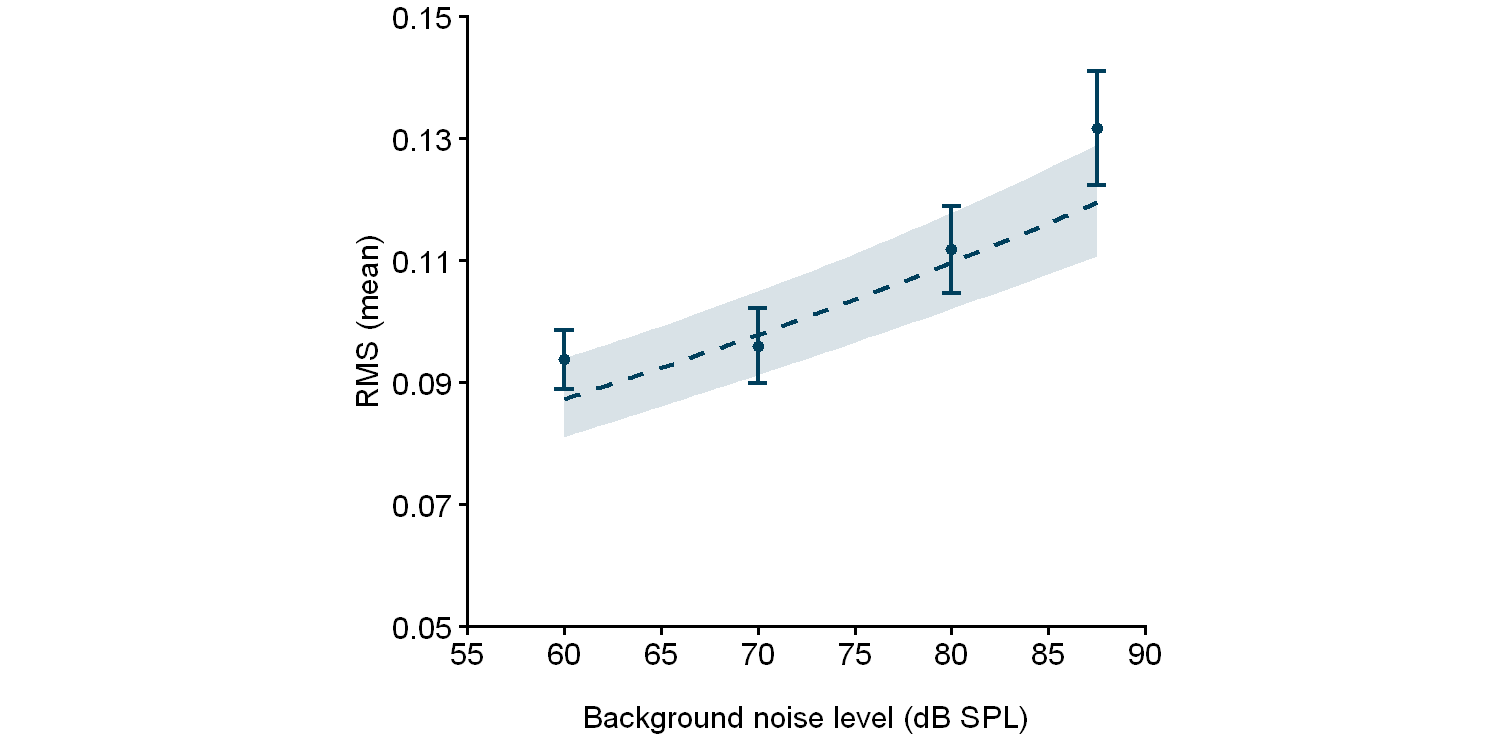

In [38]:
# Fit model (log-transformed RMS)
m2_rms <- lmer(mean_rms_log ~ environment_cent + (1 | pair), data = rms_df2)
summary(m2_rms)

# Estimated marginal means (on log scale)
emm_s2_rms <- as.data.frame(emmeans(
  m2_rms, ~ environment_cent,
  at = list(environment_cent = seq(
    min(rms_df2$environment_num, na.rm = TRUE) - mean(rms_df2$environment_num, na.rm = TRUE),
    max(rms_df2$environment_num, na.rm = TRUE) - mean(rms_df2$environment_num, na.rm = TRUE),
    length.out = 50
  )),
  infer = c(TRUE, TRUE)
))

# Map to SPL scale and back-transform
emm_s2_rms <- map_emm_to_spl(emm_s2_rms, study2_config, rms_df2) %>%
  mutate(
    emmean = exp(emmean),
    lower.CL = exp(lower.CL),
    upper.CL = exp(upper.CL)
  )

# Prepare summary data
summary_s2_rms <- summarize_by_environment(rms_df2, study2_config, "mean_rms")

# Create plot with explicit y-axis limits and breaks
p2_rms <- plot_continuous_by_spl(
  summary_df = summary_s2_rms,
  emm_df = emm_s2_rms,
  config = study2_config,
  ylabel = "RMS (mean)",
  colors = c("#003f5c", "#ffa600"),
  ylim = c(0.05, .15),
  ybreaks = seq(0.05, .15, by = 0.02)
)

print(p2_rms)

### 3.5 Combined Multi-Panel Figure: RMS Comparison

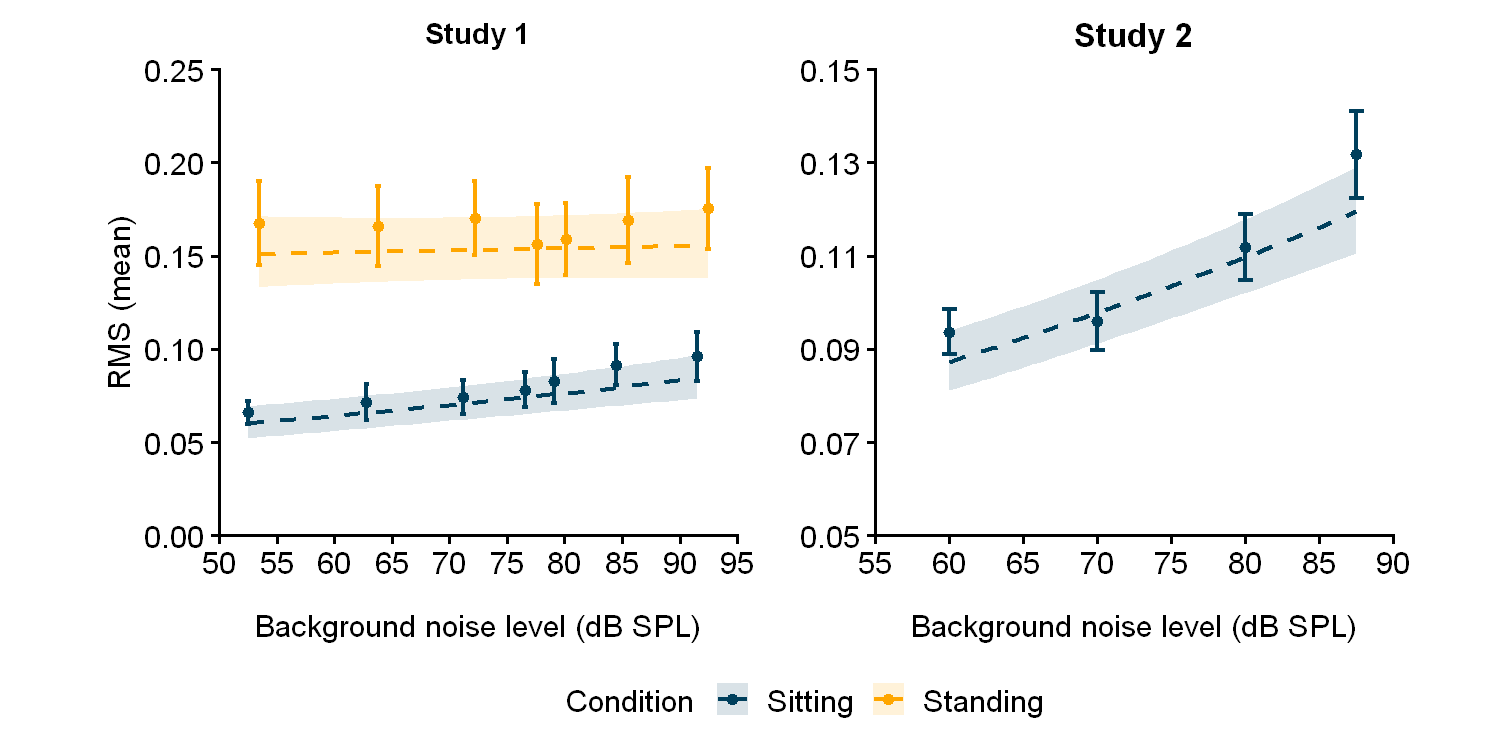

In [39]:
# Combine plots using helper function
p_rms_combined <- combine_study_plots(
  plot1 = p1_rms,
  plot2 = p2_rms,
  filename = "figures/manuscript/combined_rms_by_noise.png"
)

print(p_rms_combined)

## 4. Alpha/RMS with OIRs

### 4.1 Study 1: OIRs ~ Alpha × Condition × Environment

 Family: nbinom2  ( log )
Formula:          oirs ~ mean_alpha_cent * condition * environment_cent + (1 |  
    pair)
Data: dfa_df1

      AIC       BIC    logLik -2*log(L)  df.resid 
   1667.2    1711.5    -823.6    1647.2       606 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 pair   (Intercept) 0.1543   0.3928  
Number of obs: 616, groups:  pair, 22

Dispersion parameter for nbinom2 family (): 1.18 

Conditional model:
                                                    Estimate Std. Error z value
(Intercept)                                        -0.202698   0.122839  -1.650
mean_alpha_cent                                     1.018028   0.831608   1.224
conditionstanding                                   0.059556   0.123649   0.482
environment_cent                                    0.039605   0.007461   5.308
mean_alpha_cent:conditionstanding                   0.245981   1.079562   0.228
mean_alpha_cent:environment_cent                   -0.029299   0

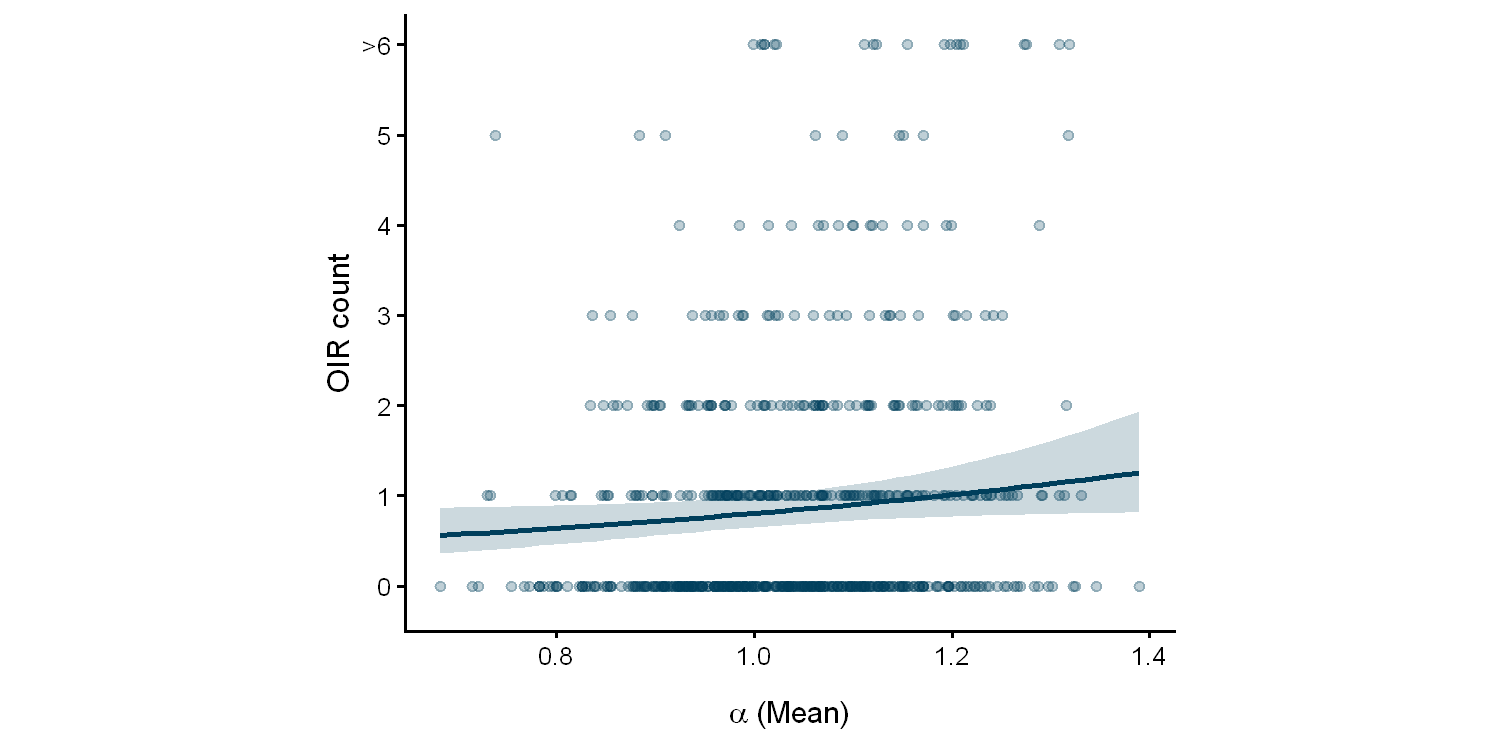

In [40]:
# Model
m1_oirs_alpha <- glmmTMB(
  oirs ~ mean_alpha_cent * condition * environment_cent + (1 | pair),
  family = nbinom2,
  data = dfa_df1
)
summary(m1_oirs_alpha)

# Create plot using helper function
p_oirs_alpha_s1 <- plot_oirs_main_effect(
  model = m1_oirs_alpha,
  data = dfa_df1,
  predictor_cent = "mean_alpha_cent",
  predictor_raw = "mean_alpha",
  xlabel = expression(alpha~"(Mean)"),
  ylim_max = 6,
  ybreaks = 1,
  cap = 6
)

### 4.2 Study 2: OIRs ~ Alpha × Environment

 Family: nbinom2  ( log )
Formula:          
oirs ~ mean_alpha_cent * environment_cent + (1 + mean_alpha_cent |      pair)
Data: dfa_df2

      AIC       BIC    logLik -2*log(L)  df.resid 
   1639.5    1672.2    -811.8    1623.5       432 

Random effects:

Conditional model:
 Groups Name            Variance Std.Dev. Corr  
 pair   (Intercept)     0.5117   0.7153         
        mean_alpha_cent 6.9223   2.6310   -0.60 
Number of obs: 440, groups:  pair, 47

Dispersion parameter for nbinom2 family (): 2.92 

Conditional model:
                                  Estimate Std. Error z value Pr(>|z|)    
(Intercept)                       0.410717   0.121318   3.385 0.000711 ***
mean_alpha_cent                   3.748104   1.331183   2.816 0.004868 ** 
environment_cent                  0.070348   0.004858  14.482  < 2e-16 ***
mean_alpha_cent:environment_cent -0.006976   0.083585  -0.083 0.933486    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

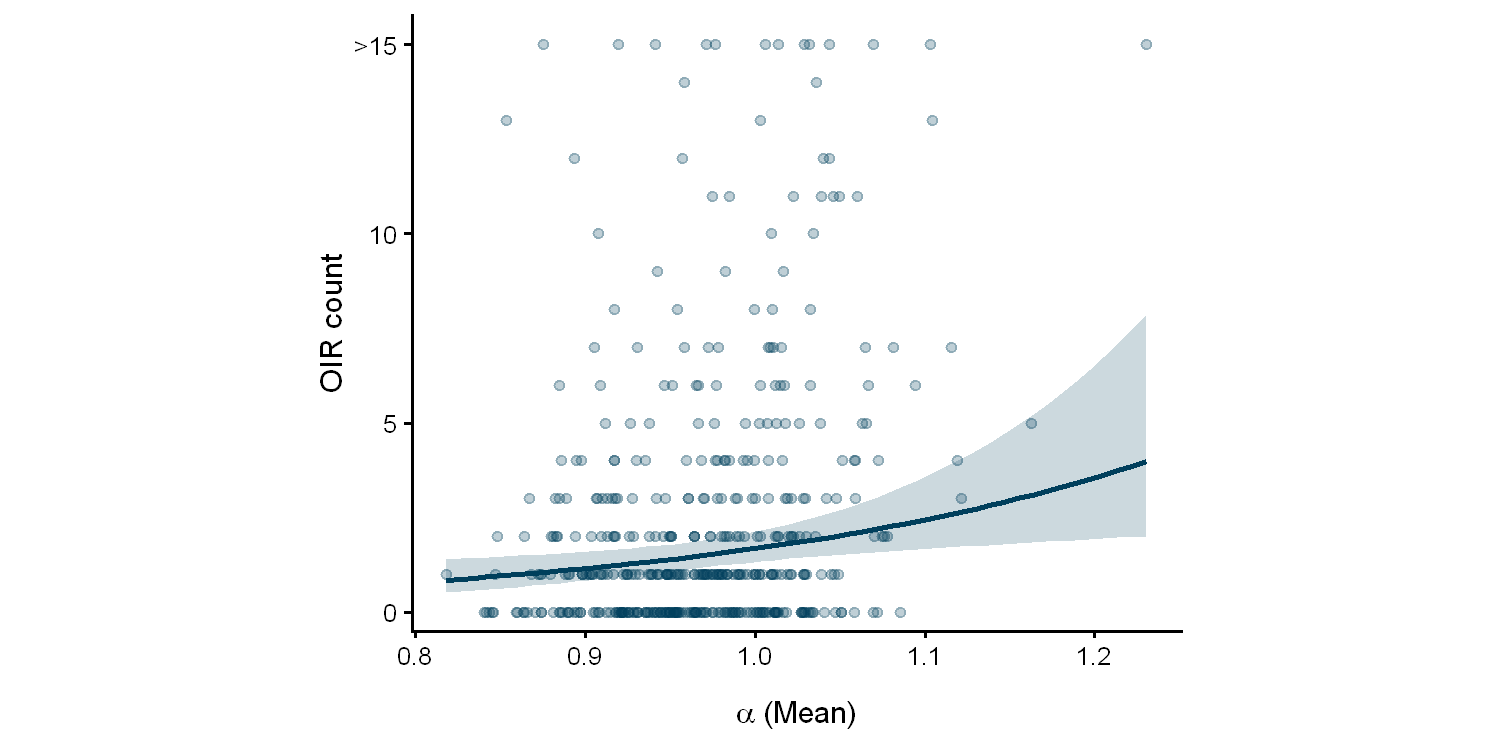

In [41]:
# Model
m2_oirs_alpha <- glmmTMB(
  oirs ~ mean_alpha_cent * environment_cent + (1 + mean_alpha_cent | pair),
  family = nbinom2,
  data = dfa_df2
)
summary(m2_oirs_alpha)

# Create plot using helper function
p_oirs_alpha <- plot_oirs_main_effect(
  model = m2_oirs_alpha,
  data = dfa_df2,
  predictor_cent = "mean_alpha_cent",
  predictor_raw = "mean_alpha",
  xlabel = expression(alpha~"(Mean)"),
  ylim_max = 15,
  ybreaks = 5,
  cap = 15,
  output_file = "figures/manuscript/study2_oirs_by_alpha.png"
)

### 4.5 Study 1: OIRs ~ RMS × Condition × Environment

In [42]:
# Model
m1_oirs_rms <- glmmTMB(
  oirs ~ mean_rms_cent * condition * environment_cent + (1 | pair),
  family = nbinom2,
  data = rms_df1
)
summary(m1_oirs_rms)

 Family: nbinom2  ( log )
Formula:          
oirs ~ mean_rms_cent * condition * environment_cent + (1 | pair)
Data: rms_df1

      AIC       BIC    logLik -2*log(L)  df.resid 
   1670.2    1714.4    -825.1    1650.2       606 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 pair   (Intercept) 0.1677   0.4095  
Number of obs: 616, groups:  pair, 22

Dispersion parameter for nbinom2 family (): 1.18 

Conditional model:
                                                 Estimate Std. Error z value
(Intercept)                                      -0.13053    0.18470  -0.707
mean_rms_cent                                     1.80409    2.88814   0.625
conditionstanding                                -0.04930    0.18941  -0.260
environment_cent                                  0.03871    0.01305   2.966
mean_rms_cent:conditionstanding                   0.11658    3.08790   0.038
mean_rms_cent:environment_cent                   -0.04375    0.22913  -0.191
conditionsta

### 4.6 Study 2: OIRs ~ RMS × Environment

In [43]:
# Model
m2_oirs_rms <- glmmTMB(
  oirs ~ mean_rms_cent * environment_cent + (1 + mean_rms_cent | pair),
  family = nbinom2,
  data = rms_df2
)
summary(m2_oirs_rms)

 Family: nbinom2  ( log )
Formula:          
oirs ~ mean_rms_cent * environment_cent + (1 + mean_rms_cent |      pair)
Data: rms_df2

      AIC       BIC    logLik -2*log(L)  df.resid 
   1644.6    1677.3    -814.3    1628.6       432 

Random effects:

Conditional model:
 Groups Name          Variance Std.Dev. Corr  
 pair   (Intercept)    0.4407  0.6638         
        mean_rms_cent 38.2508  6.1847   -0.43 
Number of obs: 440, groups:  pair, 47

Dispersion parameter for nbinom2 family (): 2.84 

Conditional model:
                               Estimate Std. Error z value Pr(>|z|)    
(Intercept)                    0.402362   0.115537   3.483 0.000497 ***
mean_rms_cent                  0.994604   2.356839   0.422 0.673019    
environment_cent               0.075073   0.005245  14.315  < 2e-16 ***
mean_rms_cent:environment_cent 0.195195   0.133546   1.462 0.143842    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

## 5. Complexity Matching Analysis

### 5.1 Study 1: CM ~ Pair Type

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: alpha_corr_z ~ pair_type + (1 | pair)
   Data: cm_df1_dyad

REML criterion at convergence: 431.3

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.0833 -0.2828 -0.0073  0.3320  5.3267 

Random effects:
 Groups   Name        Variance Std.Dev.
 pair     (Intercept) 0.001263 0.03554 
 Residual             0.114945 0.33904 
Number of obs: 616, groups:  pair, 22

Fixed effects:
                 Estimate Std. Error        df t value Pr(>|t|)    
(Intercept)       0.01238    0.02075  64.06799   0.596    0.553    
pair_typeactual   0.24128    0.02732 593.00000   8.832   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Correlation of Fixed Effects:
            (Intr)
pair_typctl -0.658

,pair_type,emmean,SE,df,lower.CL,upper.CL,t.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,pseudo,0.01237755,0.02075155,64.06799,-0.02907758,0.05383268,0.596464,5.529671e-01
2,actual,0.25366188,0.02075155,64.06799,0.21220675,0.29511701,12.223759,2.120353e-18


 contrast        estimate     SE  df t.ratio p.value
 pseudo - actual   -0.241 0.0273 593  -8.832  <.0001

Degrees-of-freedom method: kenward-roger 

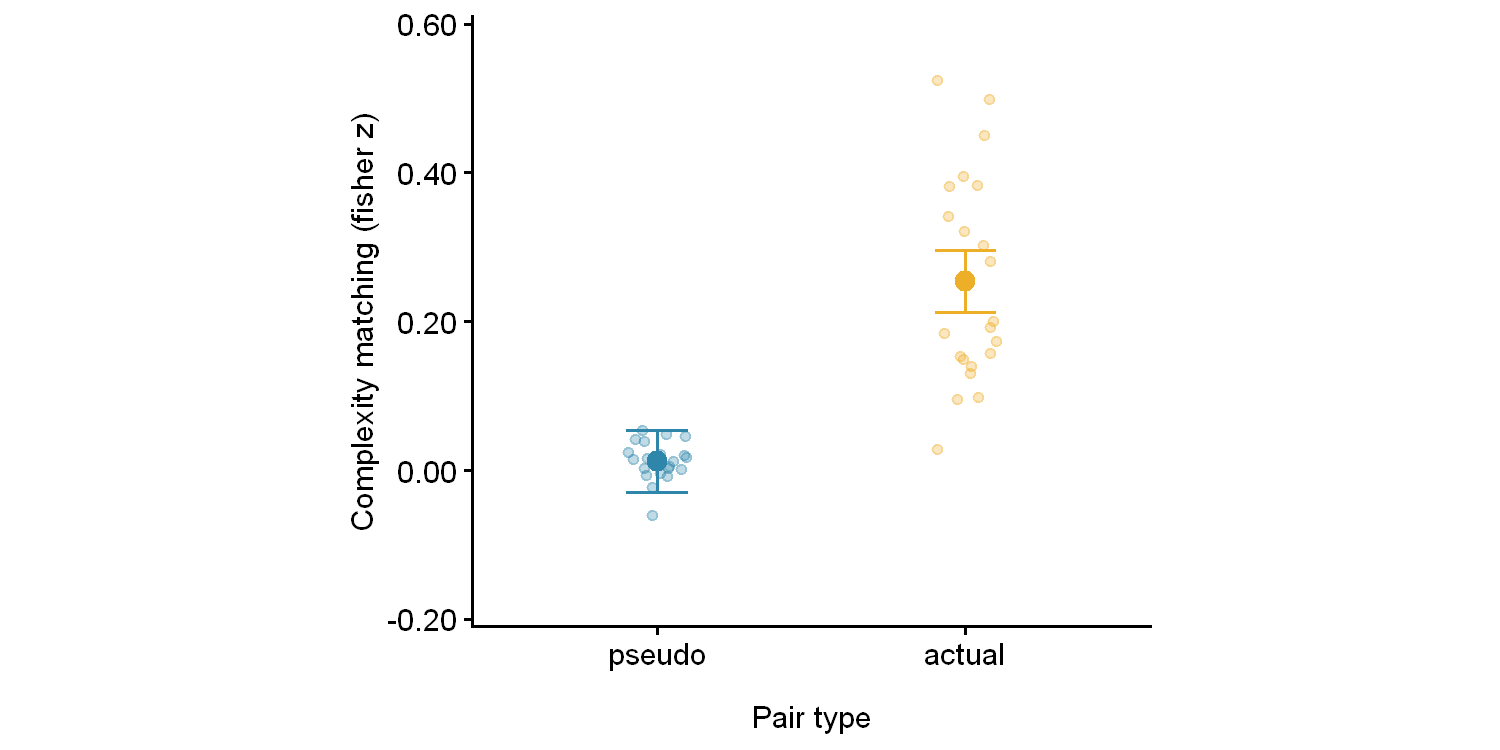

In [44]:
# Filter to dyad correlations only
cm_df1_dyad <- cm_df1 %>% filter(corr_type == "pair")

# Model
m1_cm_cat <- lmer(alpha_corr_z ~ pair_type + (1 | pair), data = cm_df1_dyad)
summary(m1_cm_cat)

# Estimated marginal means
emm_s1_cm_cat <- emmeans(m1_cm_cat, ~ pair_type, infer = c(TRUE, TRUE))
emm_s1_cm_cat_df <- as.data.frame(emm_s1_cm_cat)
emm_s1_cm_cat_df

# Pairwise comparisons
pairs(emm_s1_cm_cat, by = NULL, adjust = "tukey")

# Create plot using helper function
p_cm_cat_s1 <- create_pair_type_plot(
  dyad_data = cm_df1_dyad,
  value_var = "alpha_corr_z",
  emm_df = emm_s1_cm_cat_df,
  ylabel = "Complexity matching (fisher z)",
  ylim_min = -0.21,
  ylim_max = 0.61
)

print(p_cm_cat_s1)

### 5.1.1 Study 1: CM ~ Pair Type x Condition

In [45]:
# Model
m1_cm_cat_cond <- lmer(alpha_corr_z ~ pair_type * condition + (1 | pair), data = cm_df1_dyad)
summary(m1_cm_cat_cond)

# Estimated marginal means
emm_s1_cm_cat_cond <- emmeans(m1_cm_cat_cond, ~ pair_type * condition, infer = c(TRUE, TRUE))
emm_s1_cm_cat_cond_df <- as.data.frame(emm_s1_cm_cat_cond)
emm_s1_cm_cat_cond_df

# Pairwise comparisons
pairs(emm_s1_cm_cat_cond, by = NULL, adjust = "tukey")

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: alpha_corr_z ~ pair_type * condition + (1 | pair)
   Data: cm_df1_dyad

REML criterion at convergence: 426

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.3435 -0.2903  0.0012  0.3512  5.1601 

Random effects:
 Groups   Name        Variance Std.Dev.
 pair     (Intercept) 0.00135  0.03675 
 Residual             0.11251  0.33543 
Number of obs: 616, groups:  pair, 22

Fixed effects:
                                    Estimate Std. Error         df t value
(Intercept)                         0.012888   0.028142 187.581733   0.458
pair_typeactual                     0.167185   0.038225 591.000000   4.374
conditionstanding                  -0.001021   0.038225 591.000000  -0.027
pair_typeactual:conditionstanding   0.148198   0.054059 591.000000   2.741
                                  Pr(>|t|)    
(Intercept)                         0.6475    
pair_typeactual                   1.

,pair_type,condition,emmean,SE,df,lower.CL,upper.CL,t.ratio,p.value
,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,pseudo,sitting,0.01288804,0.02814202,187.5817,-0.04262747,0.06840356,0.4579644,6.475081e-01
2,actual,sitting,0.18007313,0.02814202,187.5817,0.12455762,0.23558865,6.3987280,1.219552e-09
3,pseudo,standing,0.01186705,0.02814202,187.5817,-0.04364846,0.06738257,0.4216845,6.737381e-01
4,actual,standing,0.32725064,0.02814202,187.5817,0.27173512,0.38276615,11.6285412,6.909652e-24


 contrast                          estimate     SE  df t.ratio p.value
 pseudo sitting - actual sitting   -0.16719 0.0382 591  -4.374  0.0001
 pseudo sitting - pseudo standing   0.00102 0.0382 591   0.027  1.0000
 pseudo sitting - actual standing  -0.31436 0.0382 591  -8.224  <.0001
 actual sitting - pseudo standing   0.16821 0.0382 591   4.400  0.0001
 actual sitting - actual standing  -0.14718 0.0382 591  -3.850  0.0008
 pseudo standing - actual standing -0.31538 0.0382 591  -8.251  <.0001

Degrees-of-freedom method: kenward-roger 
P value adjustment: tukey method for comparing a family of 4 estimates 

### 5.2 Study 2: CM ~ Pair Type

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: alpha_corr_z ~ pair_type + (1 | pair)
   Data: cm_df2_dyad

REML criterion at convergence: -382.2

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.1616 -0.2595 -0.0098  0.2562  4.3846 

Random effects:
 Groups   Name        Variance Std.Dev.
 pair     (Intercept) 0.000475 0.0218  
 Residual             0.026114 0.1616  
Number of obs: 499, groups:  pair, 46

Fixed effects:
                 Estimate Std. Error        df t value Pr(>|t|)   
(Intercept)     4.976e-03  1.033e-02 1.280e+02   0.482  0.63096   
pair_typeactual 4.046e-02  1.456e-02 4.742e+02   2.779  0.00566 **
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Correlation of Fixed Effects:
            (Intr)
pair_typctl -0.640

,pair_type,emmean,SE,df,lower.CL,upper.CL,t.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,pseudo,0.00497615,0.01033481,124.1217,-0.01547914,0.02543144,0.481494,6.310133e-01
2,actual,0.04543235,0.01124409,142.2495,0.02320525,0.06765945,4.040555,8.691921e-05


 contrast        estimate     SE  df t.ratio p.value
 pseudo - actual  -0.0405 0.0146 473  -2.777  0.0057

Degrees-of-freedom method: kenward-roger 

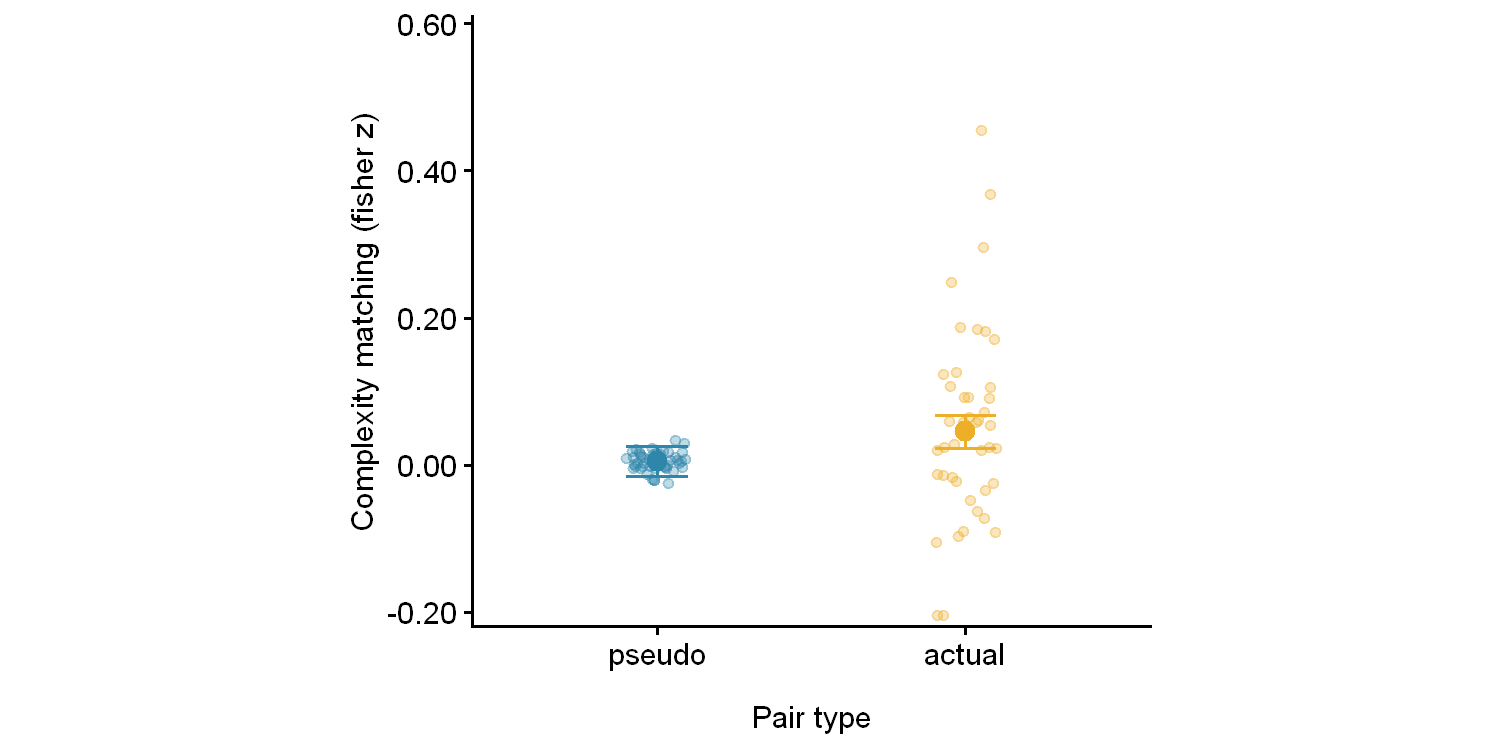

In [46]:
# Filter to dyad correlations only
cm_df2_dyad <- cm_df2 %>% filter(corr_type == "pair")

# Model
m2_cm_cat <- lmer(alpha_corr_z ~ pair_type + (1 | pair), data = cm_df2_dyad)
summary(m2_cm_cat)

# Estimated marginal means
emm_s2_cm_cat <- emmeans(m2_cm_cat, ~ pair_type, infer = c(TRUE, TRUE))
emm_s2_cm_cat_df <- as.data.frame(emm_s2_cm_cat)
emm_s2_cm_cat_df

# Pairwise comparisons
pairs(emm_s2_cm_cat, by = NULL, adjust = "tukey")

# Create plot using helper function
p_cm_cat_s2 <- create_pair_type_plot(
  dyad_data = cm_df2_dyad,
  value_var = "alpha_corr_z",
  emm_df = emm_s2_cm_cat_df,
  ylabel = "Complexity matching (fisher z)",
  ylim_min = -0.22,
  ylim_max = 0.61
)

print(p_cm_cat_s2)

### 5.5 Combined Multi-Panel Figure: Complexity Matching Comparison

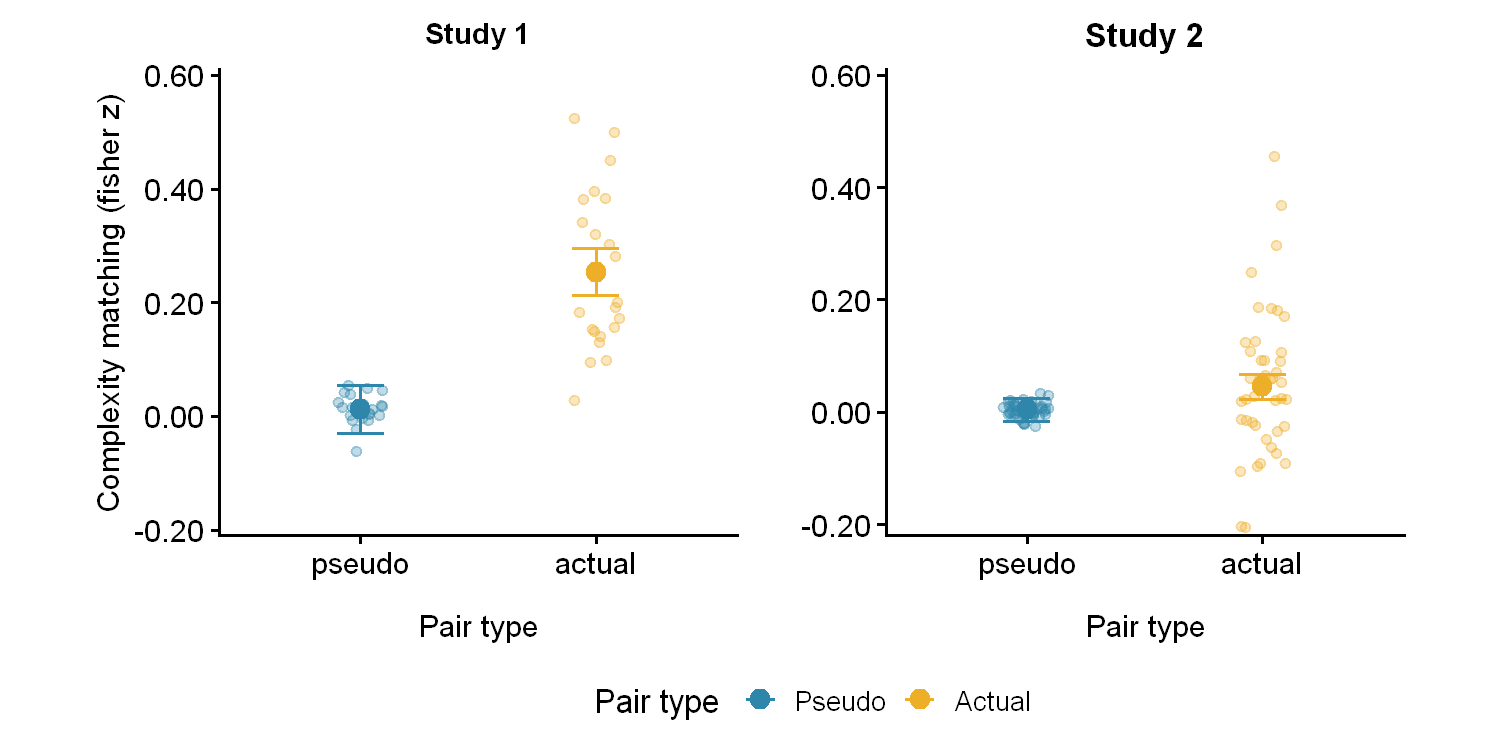

In [47]:
# Combine plots using helper function
p_cm_cat_combined <- combine_study_plots(
  plot1 = p_cm_cat_s1,
  plot2 = p_cm_cat_s2,
  filename = "figures/manuscript/combined_cm_by_categorical.png")

print(p_cm_cat_combined)

## 6. RMS Cross Correlation Analysis

### 6.1 Study 1: RMS Corr ~ Pair Type

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: rms_corr_z ~ pair_type + (1 | pair)
   Data: cm_df1_dyad

REML criterion at convergence: 789.8

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.6799 -0.3639 -0.0174  0.2984  5.6315 

Random effects:
 Groups   Name        Variance Std.Dev.
 pair     (Intercept) 0.008456 0.09195 
 Residual             0.202549 0.45005 
Number of obs: 616, groups:  pair, 22

Fixed effects:
                 Estimate Std. Error        df t value Pr(>|t|)    
(Intercept)       0.02722    0.03228  44.49386   0.843    0.404    
pair_typeactual   0.40170    0.03627 593.00000  11.076   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Correlation of Fixed Effects:
            (Intr)
pair_typctl -0.562

,pair_type,emmean,SE,df,lower.CL,upper.CL,t.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,pseudo,0.02722109,0.03227969,44.49386,-0.03781397,0.09225615,0.8432884,4.035780e-01
2,actual,0.42892192,0.03227969,44.49386,0.36388686,0.49395698,13.2876699,4.299964e-17


 contrast        estimate     SE  df t.ratio p.value
 pseudo - actual   -0.402 0.0363 593 -11.076  <.0001

Degrees-of-freedom method: kenward-roger 

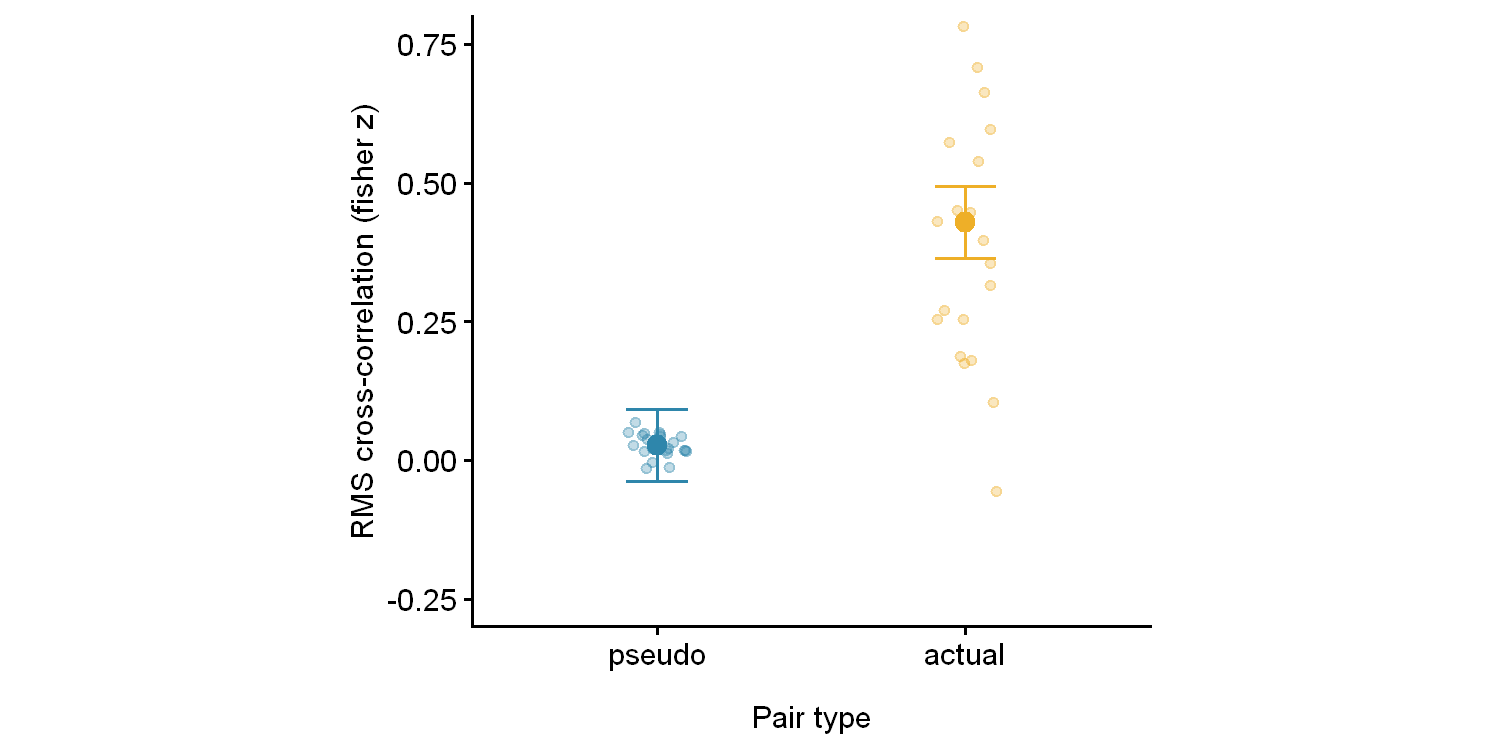

In [48]:
# Model
m1_rms_cat <- lmer(rms_corr_z ~ pair_type + (1 | pair), data = cm_df1_dyad)
summary(m1_rms_cat)

# Estimated marginal means
emm_s1_rms_cat <- emmeans(m1_rms_cat, ~ pair_type, infer = c(TRUE, TRUE))
emm_s1_rms_cat_df <- as.data.frame(emm_s1_rms_cat)
emm_s1_rms_cat_df

# Pairwise comparisons
pairs(emm_s1_rms_cat, by = NULL, adjust = "tukey")

# Create plot using helper function
p_rms_cat_s1 <- create_pair_type_plot(
  dyad_data = cm_df1_dyad,
  value_var = "rms_corr_z",
  emm_df = emm_s1_rms_cat_df,
  ylabel = "RMS cross-correlation (fisher z)",
  ylim_min = -0.30,
  ylim_max = 0.80
)

print(p_rms_cat_s1)

### 6.2 Study 2: RMS Corr ~ Pair Type

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: rms_corr_z ~ pair_type + (1 | pair)
   Data: cm_df2_dyad

REML criterion at convergence: -183.5

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.3381 -0.2610  0.0011  0.2494  3.6910 

Random effects:
 Groups   Name        Variance Std.Dev.
 pair     (Intercept) 0.002106 0.04589 
 Residual             0.037940 0.19478 
Number of obs: 499, groups:  pair, 46

Fixed effects:
                 Estimate Std. Error        df t value Pr(>|t|)    
(Intercept)     6.133e-03  1.364e-02 1.045e+02   0.449    0.654    
pair_typeactual 8.739e-02  1.760e-02 4.720e+02   4.964 9.67e-07 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Correlation of Fixed Effects:
            (Intr)
pair_typctl -0.582

,pair_type,emmean,SE,df,lower.CL,upper.CL,t.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,pseudo,0.006132843,0.01364630,100.6375,-0.02093893,0.03320462,0.4494142,6.540993e-01
2,actual,0.093523092,0.01473154,118.8849,0.06435287,0.12269331,6.3484920,4.124310e-09


 contrast        estimate     SE  df t.ratio p.value
 pseudo - actual  -0.0874 0.0176 471  -4.960  <.0001

Degrees-of-freedom method: kenward-roger 

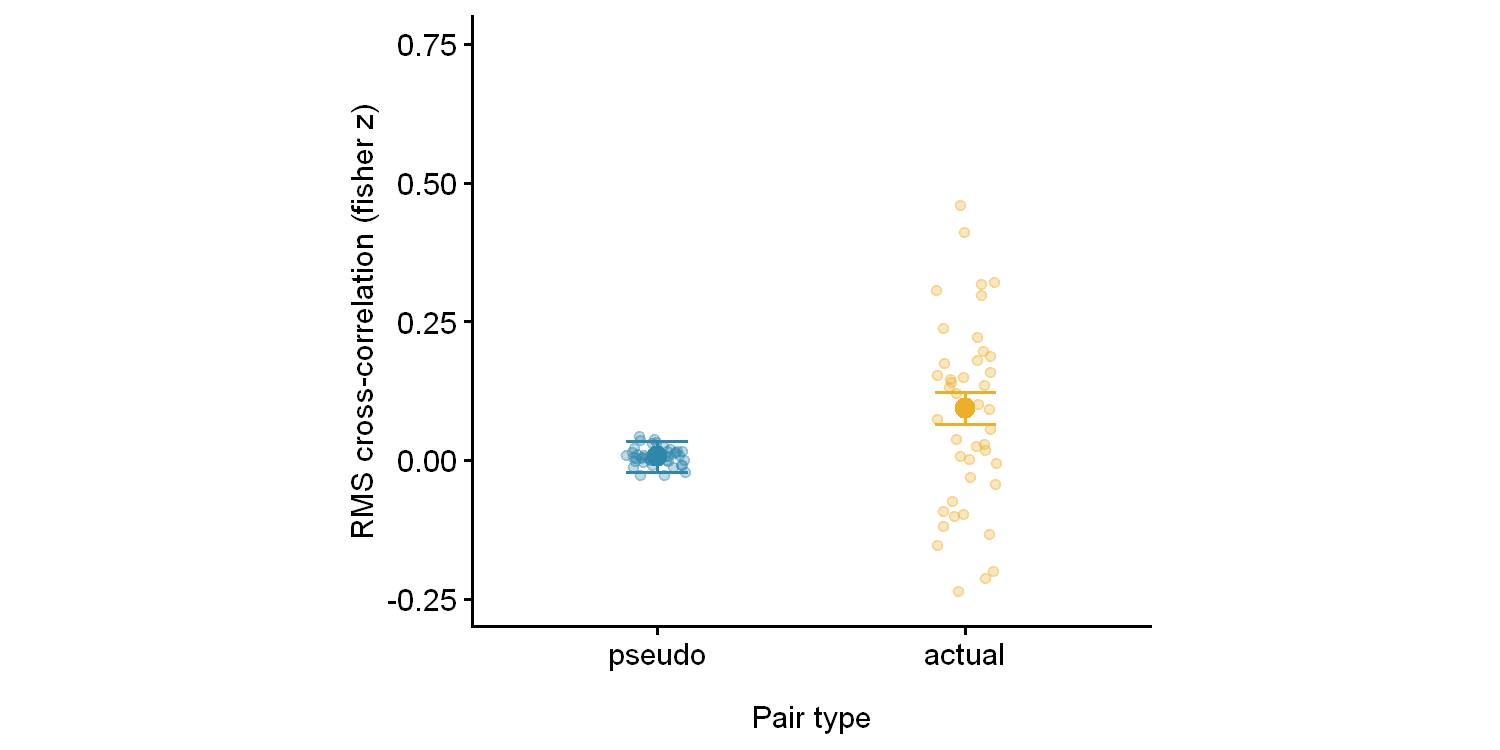

In [49]:
# Model
m2_rms_cat <- lmer(rms_corr_z ~ pair_type + (1 | pair), data = cm_df2_dyad)
summary(m2_rms_cat)

# Estimated marginal means
emm_s2_rms_cat <- emmeans(m2_rms_cat, ~ pair_type, infer = c(TRUE, TRUE))
emm_s2_rms_cat_df <- as.data.frame(emm_s2_rms_cat)
emm_s2_rms_cat_df

# Pairwise comparisons
pairs(emm_s2_rms_cat, by = NULL, adjust = "tukey")

# Create plot using helper function
p_rms_cat_s2 <- create_pair_type_plot(
  dyad_data = cm_df2_dyad,
  value_var = "rms_corr_z",
  emm_df = emm_s2_rms_cat_df,
  ylabel = "RMS cross-correlation (fisher z)",
  ylim_min = -0.30,
  ylim_max = 0.80
)

print(p_rms_cat_s2)

### 6.5 Combined Multi-Panel Figure: RMS Cross-Correlation Comparison

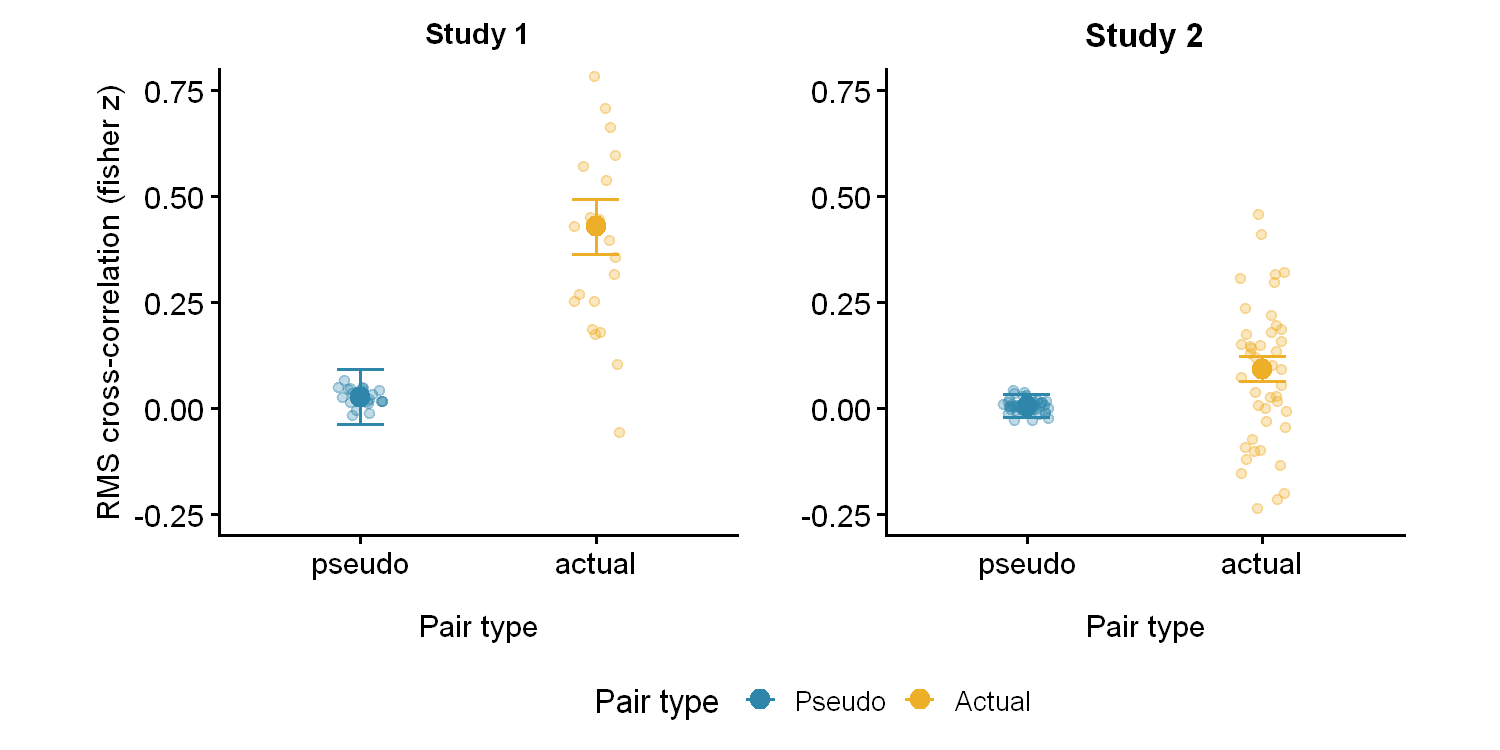

In [50]:
# Combine plots using helper function
p_rms_cat_combined <- combine_study_plots(
  plot1 = p_rms_cat_s1,
  plot2 = p_rms_cat_s2,
  filename = "figures/manuscript/combined_rms_cor_by_categorical.png"
)

print(p_rms_cat_combined)

## 7. Complexity Matching & Background Noise

### 7.1 Study 1: CM ~ Pair Type x Environment x Condition

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: alpha_corr_z ~ condition * pair_type * environment_cent + (1 |  
    pair)
   Data: cm_df1_dyad

REML criterion at convergence: 455.9

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.1244 -0.2963  0.0064  0.3563  4.8089 

Random effects:
 Groups   Name        Variance Std.Dev.
 pair     (Intercept) 0.001402 0.03745 
 Residual             0.111053 0.33325 
Number of obs: 616, groups:  pair, 22

Fixed effects:
                                                     Estimate Std. Error
(Intercept)                                          0.012888   0.028015
conditionstanding                                   -0.001021   0.037977
pair_typeactual                                      0.167185   0.037977
environment_cent                                     0.000488   0.002198
conditionstanding:pair_typeactual                    0.148199   0.053707
conditionstanding:environment_cent      

,condition,pair_type,environment_cent.trend,SE,df,lower.CL,upper.CL,t.ratio,p.value
,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,sitting,pseudo,0.0004879674,0.002198053,587,-0.003829039,0.004804974,0.2219998,0.824391255
2,standing,pseudo,-0.0011912699,0.002198053,587,-0.005508277,0.003125737,-0.5419659,0.588047679
3,sitting,actual,-0.0014252139,0.002198053,587,-0.005742221,0.002891793,-0.6483982,0.516980989
4,standing,actual,0.0072896330,0.002198053,587,0.002972626,0.011606640,3.3164040,0.000968153


 contrast                           estimate      SE  df t.ratio p.value
 sitting pseudo - standing pseudo   0.001679 0.00311 587   0.540  0.9491
 sitting pseudo - sitting actual    0.001913 0.00311 587   0.615  0.9271
 sitting pseudo - standing actual  -0.006802 0.00311 587  -2.188  0.1277
 standing pseudo - sitting actual   0.000234 0.00311 587   0.075  0.9998
 standing pseudo - standing actual -0.008481 0.00311 587  -2.728  0.0331
 sitting actual - standing actual  -0.008715 0.00311 587  -2.804  0.0268

Degrees-of-freedom method: kenward-roger 
P value adjustment: tukey method for comparing a family of 4 estimates 

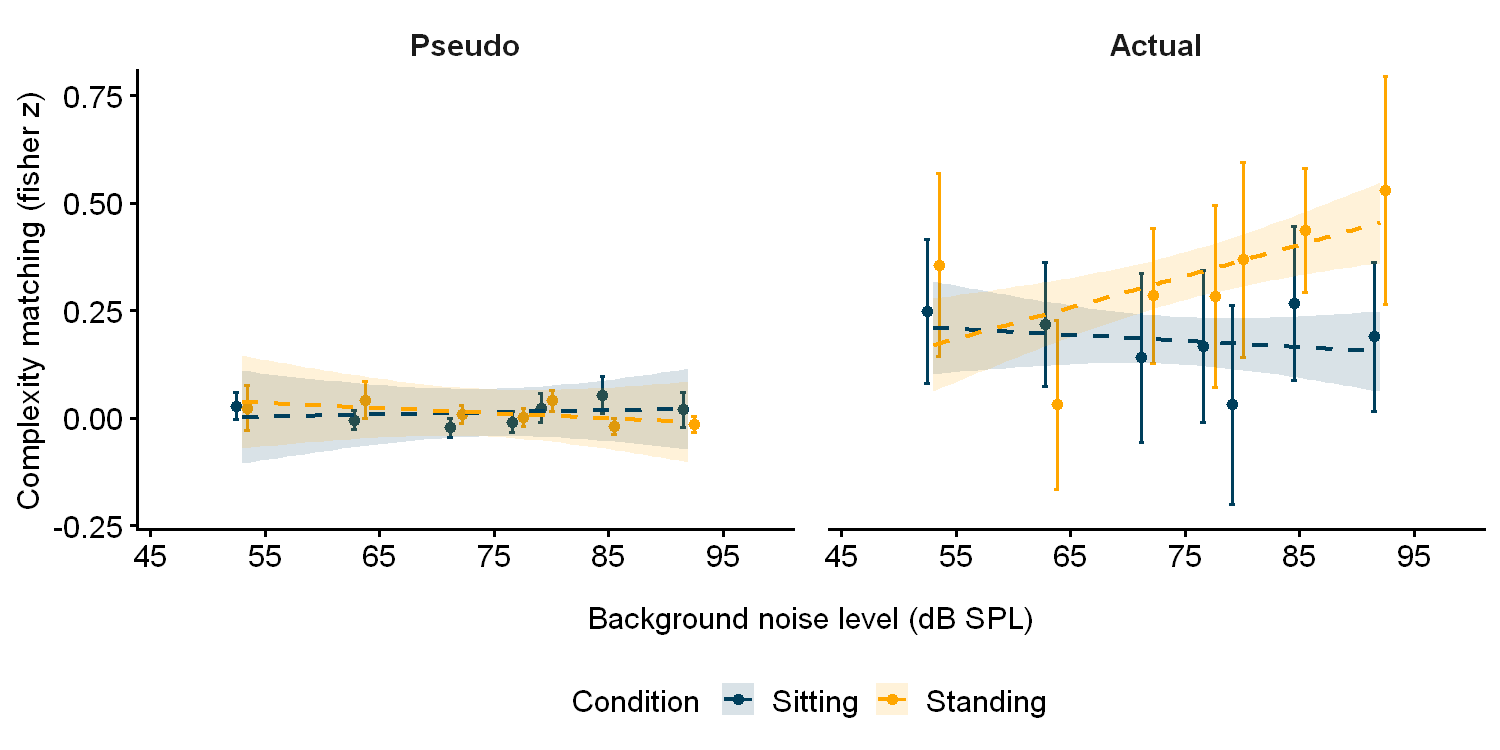

In [51]:
# Model
m1_cm_cont <- lmer(alpha_corr_z ~ condition * pair_type * environment_cent + (1 | pair), data = cm_df1_dyad)
summary(m1_cm_cont)

# Estimated marginal means
emm_s1_cm_cont <- emmeans(
  m1_cm_cont, ~ condition * pair_type * environment_cent,
  at = list(environment_cent = seq(
    min(cm_df1_dyad$environment_num, na.rm = TRUE) - mean(cm_df1_dyad$environment_num, na.rm = TRUE),
    max(cm_df1_dyad$environment_num, na.rm = TRUE) - mean(cm_df1_dyad$environment_num, na.rm = TRUE),
    length.out = 50
  )),
  infer = c(TRUE, TRUE)
)
emm_s1_cm_cont_df <- as.data.frame(emm_s1_cm_cont)

# Map to SPL scale
emm_s1_cm_cont_df <- map_emm_to_spl(emm_s1_cm_cont_df, study1_config, cm_df1_dyad)

# Test slopes (emtrends)
emtrends_s1_cm <- emtrends(m1_cm_cont, ~ condition * pair_type, var = "environment_cent", infer = c(TRUE, TRUE))
emtrends_s1_cm_df <- as.data.frame(emtrends_s1_cm)
emtrends_s1_cm_df

# Pairwise slope comparisons
pairs(emtrends_s1_cm, by = NULL, adjust = "tukey")

# Create plot using helper function
p_cm_cont_s1 <- create_continuous_pair_type_plot(
  dyad_data = cm_df1_dyad,
  value_var = "alpha_corr_z",
  emm_df = emm_s1_cm_cont_df,
  study_config = study1_config,
  ylabel = "Complexity matching (fisher z)",
  has_condition = TRUE,
  x_breaks = seq(45, 100, by = 10),
  x_limits = c(45, 100),
  y_limits = c(-0.21, 0.76),
  output_file = "figures/manuscript/study1_cm_by_manip.png"
)

print(p_cm_cont_s1)

### 7.2 Study 2: CM ~ Pair Type x Environment

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: alpha_corr_z ~ pair_type * environment_cent + (1 | pair)
   Data: cm_df2_dyad

REML criterion at convergence: -360.1

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.2436 -0.2529 -0.0083  0.2354  4.3033 

Random effects:
 Groups   Name        Variance  Std.Dev.
 pair     (Intercept) 0.0004594 0.02143 
 Residual             0.0261229 0.16163 
Number of obs: 499, groups:  pair, 46

Fixed effects:
                                   Estimate Std. Error         df t value
(Intercept)                       4.980e-03  1.032e-02  1.285e+02   0.483
pair_typeactual                   3.960e-02  1.457e-02  4.724e+02   2.718
environment_cent                 -1.933e-04  9.058e-04  4.532e+02  -0.213
pair_typeactual:environment_cent -1.250e-03  1.358e-03  4.587e+02  -0.921
                                 Pr(>|t|)   
(Intercept)                       0.63022   
pair_typeactual                 

,pair_type,environment_cent.trend,SE,df,lower.CL,upper.CL,t.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,pseudo,-0.0001933182,0.0009057755,451.5624,-0.001973377,0.0015867401,-0.2134284,0.8310892
2,actual,-0.0014432486,0.0010121272,462.1209,-0.003432191,0.0005456934,-1.4259557,0.1545563


 contrast        estimate      SE  df t.ratio p.value
 pseudo - actual  0.00125 0.00136 457   0.920  0.3579

Degrees-of-freedom method: kenward-roger 

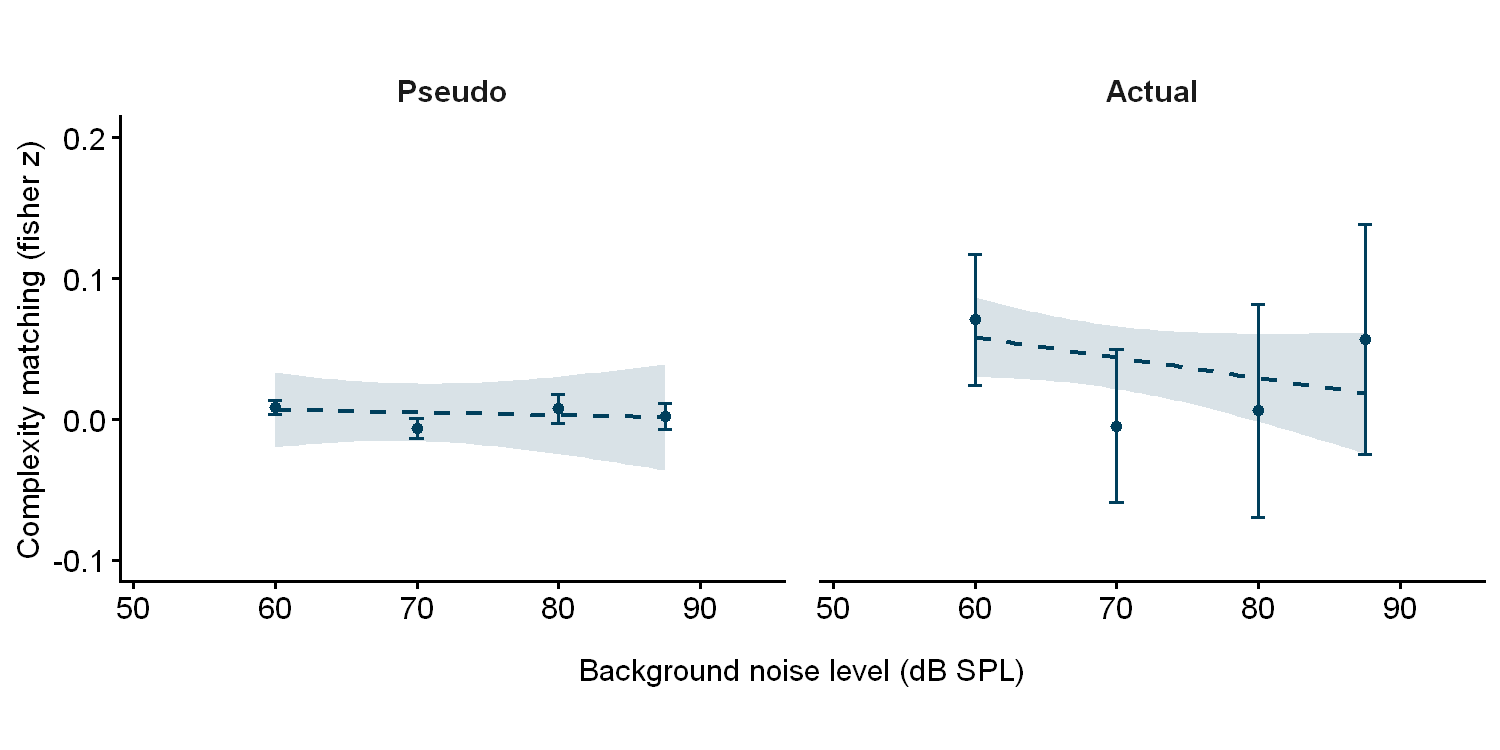

In [52]:
# Model
m2_cm_cont <- lmer(alpha_corr_z ~ pair_type * environment_cent + (1 | pair), data = cm_df2_dyad)
summary(m2_cm_cont)

# Estimated marginal means
emm_s2_cm_cont <- emmeans(
  m2_cm_cont, ~ pair_type * environment_cent,
  at = list(environment_cent = seq(
    min(cm_df2_dyad$environment_num, na.rm = TRUE) - mean(cm_df2_dyad$environment_num, na.rm = TRUE),
    max(cm_df2_dyad$environment_num, na.rm = TRUE) - mean(cm_df2_dyad$environment_num, na.rm = TRUE),
    length.out = 50
  )),
  infer = c(TRUE, TRUE)
)
emm_s2_cm_cont_df <- as.data.frame(emm_s2_cm_cont)

# Map to SPL scale
emm_s2_cm_cont_df <- map_emm_to_spl(emm_s2_cm_cont_df, study2_config, cm_df2_dyad)

# Test slopes (emtrends)
emtrends_s2_cm <- emtrends(m2_cm_cont, ~ pair_type, var = "environment_cent", infer = c(TRUE, TRUE))
emtrends_s2_cm_df <- as.data.frame(emtrends_s2_cm)
emtrends_s2_cm_df

# Pairwise slope comparisons
pairs(emtrends_s2_cm, by = NULL, adjust = "tukey")

# Create plot using helper function
p_cm_cont_s2 <- create_continuous_pair_type_plot(
  dyad_data = cm_df2_dyad,
  value_var = "alpha_corr_z",
  emm_df = emm_s2_cm_cont_df,
  study_config = study2_config,
  ylabel = "Complexity matching (fisher z)",
  has_condition = FALSE,
  x_breaks = seq(50, 95, by = 10),
  x_limits = c(50, 95),
  y_limits = c(-0.10, 0.20)
)

print(p_cm_cont_s2)

## 8. RMS Cross Correlation & Background Noise

### 8.1 Study 1: RMS Corr ~ Pair Type x Environment x Condition

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: rms_corr_z ~ condition * environment_cent * pair_type + (1 |  
    pair)
   Data: cm_df1_dyad

REML criterion at convergence: 748.3

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.5382 -0.3742 -0.0213  0.3298  5.4779 

Random effects:
 Groups   Name        Variance Std.Dev.
 pair     (Intercept) 0.009408 0.0970  
 Residual             0.175876 0.4194  
Number of obs: 616, groups:  pair, 22

Fixed effects:
                                                     Estimate Std. Error
(Intercept)                                         3.143e-02  3.962e-02
conditionstanding                                  -8.421e-03  4.779e-02
environment_cent                                    3.583e-04  2.766e-03
pair_typeactual                                     2.229e-01  4.779e-02
conditionstanding:environment_cent                 -2.481e-04  3.912e-03
conditionstanding:pair_typeactual         

,condition,pair_type,environment_cent.trend,SE,df,lower.CL,upper.CL,t.ratio,p.value
,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,sitting,pseudo,0.0003582632,0.002766157,587,-0.005074507,0.005791034,0.1295165,8.969933e-01
2,standing,pseudo,0.0001101506,0.002766157,587,-0.005322620,0.005542921,0.0398208,9.682495e-01
3,sitting,actual,-0.0007860913,0.002766157,587,-0.006218862,0.004646679,-0.2841817,7.763714e-01
4,standing,actual,0.0180198476,0.002766157,587,0.012587077,0.023452618,6.5143971,1.570701e-10


 contrast                           estimate      SE  df t.ratio p.value
 sitting pseudo - standing pseudo   0.000248 0.00391 587   0.063  0.9999
 sitting pseudo - sitting actual    0.001144 0.00391 587   0.293  0.9913
 sitting pseudo - standing actual  -0.017662 0.00391 587  -4.515  <.0001
 standing pseudo - sitting actual   0.000896 0.00391 587   0.229  0.9958
 standing pseudo - standing actual -0.017910 0.00391 587  -4.578  <.0001
 sitting actual - standing actual  -0.018806 0.00391 587  -4.807  <.0001

Degrees-of-freedom method: kenward-roger 
P value adjustment: tukey method for comparing a family of 4 estimates 

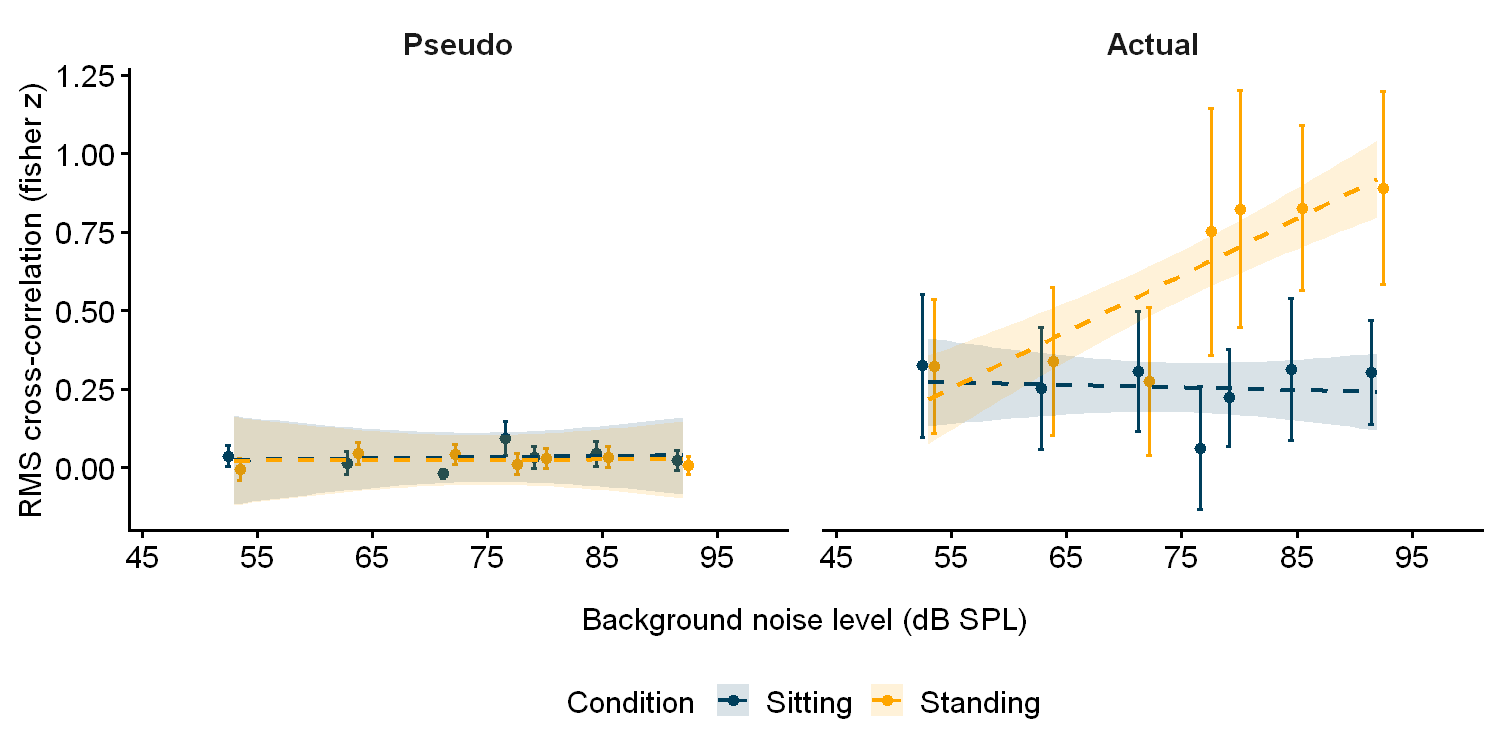

In [53]:
# Model
m1_rms_cont <- lmer(rms_corr_z ~ condition * environment_cent * pair_type + (1 | pair), data = cm_df1_dyad)
summary(m1_rms_cont)

# Estimated marginal means
emm_s1_rms_cont <- emmeans(
  m1_rms_cont, ~ condition * pair_type * environment_cent,
  at = list(environment_cent = seq(
    min(cm_df1_dyad$environment_num, na.rm = TRUE) - mean(cm_df1_dyad$environment_num, na.rm = TRUE),
    max(cm_df1_dyad$environment_num, na.rm = TRUE) - mean(cm_df1_dyad$environment_num, na.rm = TRUE),
    length.out = 50
  )),
  infer = c(TRUE, TRUE)
)
emm_s1_rms_cont_df <- as.data.frame(emm_s1_rms_cont)

# Map to SPL scale
emm_s1_rms_cont_df <- map_emm_to_spl(emm_s1_rms_cont_df, study1_config, cm_df1_dyad)

# Test slopes (emtrends)
emtrends_s1_rms <- emtrends(m1_rms_cont, ~ condition * pair_type, var = "environment_cent", infer = c(TRUE, TRUE))
emtrends_s1_rms_df <- as.data.frame(emtrends_s1_rms)
emtrends_s1_rms_df

# Pairwise slope comparisons
pairs(emtrends_s1_rms, by = NULL, adjust = "tukey")

# Create plot using helper function
p <- create_continuous_pair_type_plot(
  dyad_data = cm_df1_dyad,
  value_var = "rms_corr_z",
  emm_df = emm_s1_rms_cont_df,
  study_config = study1_config,
  ylabel = "RMS cross-correlation (fisher z)",
  has_condition = TRUE,
  x_breaks = seq(45, 100, by = 10),
  x_limits = c(45, 100),
  output_file = "figures/manuscript/study1_rms_cor_by_manip.png"
)

print(p)

### 8.2 Study 2: RMS Corr ~ Pair Type x Environment

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: rms_corr_z ~ environment_cent * pair_type + (1 | pair)
   Data: cm_df2_dyad

REML criterion at convergence: -162.9

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.3500 -0.2715 -0.0056  0.2474  3.7877 

Random effects:
 Groups   Name        Variance Std.Dev.
 pair     (Intercept) 0.002143 0.04629 
 Residual             0.037856 0.19457 
Number of obs: 499, groups:  pair, 46

Fixed effects:
                                   Estimate Std. Error         df t value
(Intercept)                       6.147e-03  1.366e-02  1.040e+02   0.450
environment_cent                 -2.227e-04  1.090e-03  4.531e+02  -0.204
pair_typeactual                   8.860e-02  1.760e-02  4.702e+02   5.033
environment_cent:pair_typeactual  2.238e-03  1.636e-03  4.574e+02   1.368
                                 Pr(>|t|)    
(Intercept)                         0.654    
environment_cent                   

,pair_type,environment_cent.trend,SE,df,lower.CL,upper.CL,t.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,pseudo,-0.0002227352,0.001090423,451.1473,-0.0023656736,0.001920203,-0.204265,0.83823853
2,actual,0.0020149752,0.001220391,459.5633,-0.0003832625,0.004413213,1.651090,0.09940327


 contrast        estimate      SE  df t.ratio p.value
 pseudo - actual -0.00224 0.00164 456  -1.367  0.1722

Degrees-of-freedom method: kenward-roger 

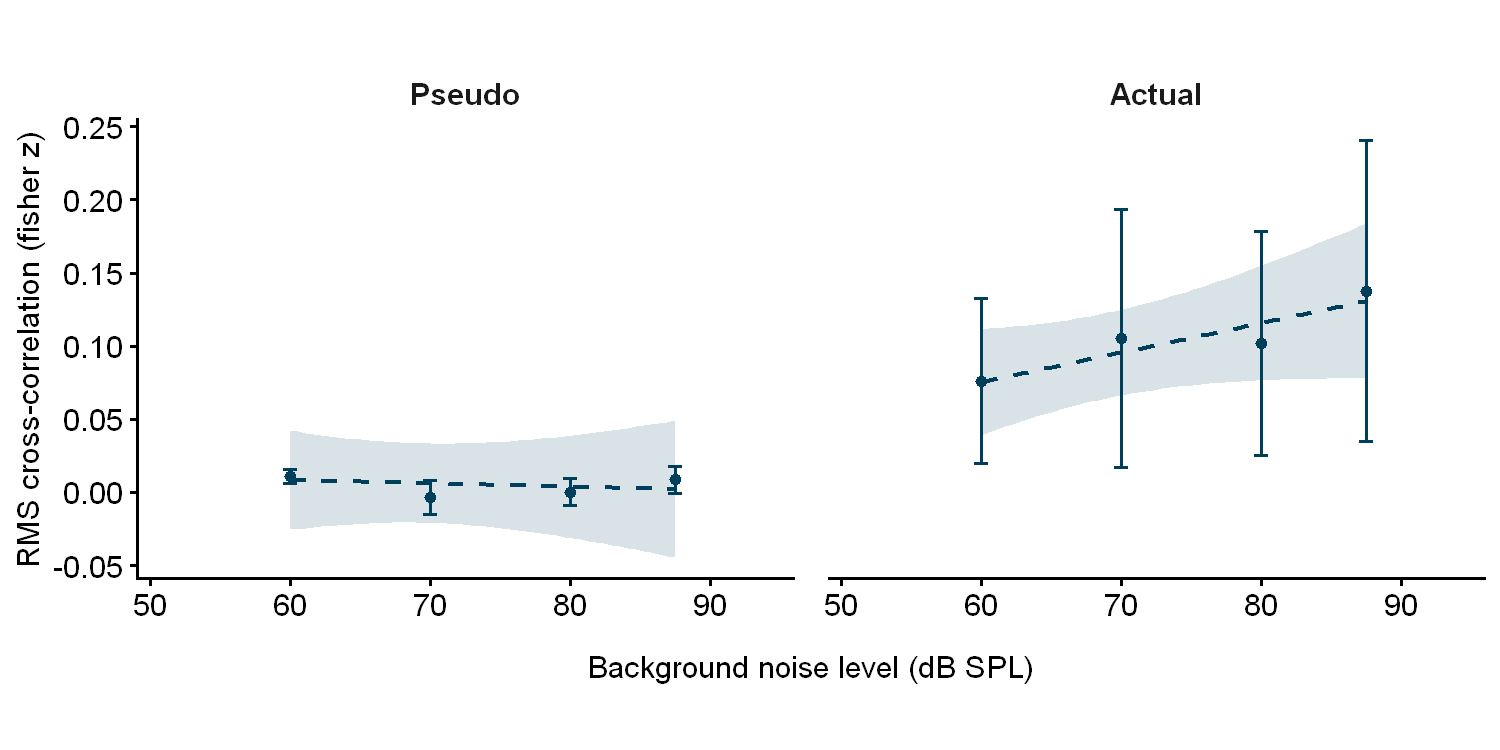

In [54]:
# Model (using same filtered data from Section 7)
m2_rms_cont <- lmer(rms_corr_z ~ environment_cent * pair_type + (1 | pair), data = cm_df2_dyad)
summary(m2_rms_cont)

# Estimated marginal means
emm_s2_rms_cont <- emmeans(
  m2_rms_cont, ~ pair_type * environment_cent,
  at = list(environment_cent = seq(
    min(cm_df2_dyad$environment_num, na.rm = TRUE) - mean(cm_df2_dyad$environment_num, na.rm = TRUE),
    max(cm_df2_dyad$environment_num, na.rm = TRUE) - mean(cm_df2_dyad$environment_num, na.rm = TRUE),
    length.out = 50
  )),
  infer = c(TRUE, TRUE)
)
emm_s2_rms_cont_df <- as.data.frame(emm_s2_rms_cont)

# Map to SPL scale
emm_s2_rms_cont_df <- map_emm_to_spl(emm_s2_rms_cont_df, study2_config, cm_df2_dyad)

# Test slopes (emtrends)
emtrends_s2_rms <- emtrends(m2_rms_cont, ~ pair_type, var = "environment_cent", infer = c(TRUE, TRUE))
emtrends_s2_rms_df <- as.data.frame(emtrends_s2_rms)
emtrends_s2_rms_df

# Pairwise slope comparisons
pairs(emtrends_s2_rms, by = NULL, adjust = "tukey")

# Create plot using helper function
p <- create_continuous_pair_type_plot(
  dyad_data = cm_df2_dyad,
  value_var = "rms_corr_z",
  emm_df = emm_s2_rms_cont_df,
  study_config = study2_config,
  ylabel = "RMS cross-correlation (fisher z)",
  has_condition = FALSE,
  x_breaks = seq(50, 95, by = 10),
  x_limits = c(50, 95)
)

print(p)

## 9. Complexity Matching with OIRS

### 9.1 Study 1: OIRs ~ CM × Condition × Environment

 Family: nbinom2  ( log )
Formula:          
oirs ~ alpha_corr_z * condition * environment_cent + (1 | pair)
Data: cm_oirs_s1

      AIC       BIC    logLik -2*log(L)  df.resid 
   1143.2    1180.5    -561.6    1123.2       298 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 pair   (Intercept) 0.1704   0.4128  
Number of obs: 308, groups:  pair, 22

Dispersion parameter for nbinom2 family (): 2.39 

Conditional model:
                                                Estimate Std. Error z value
(Intercept)                                      0.43964    0.13103   3.355
alpha_corr_z                                     0.13833    0.19448   0.711
conditionstanding                                0.19780    0.13582   1.456
environment_cent                                 0.04847    0.00863   5.616
alpha_corr_z:conditionstanding                  -0.19995    0.26104  -0.766
alpha_corr_z:environment_cent                   -0.02679    0.01876  -1.428
conditionstanding

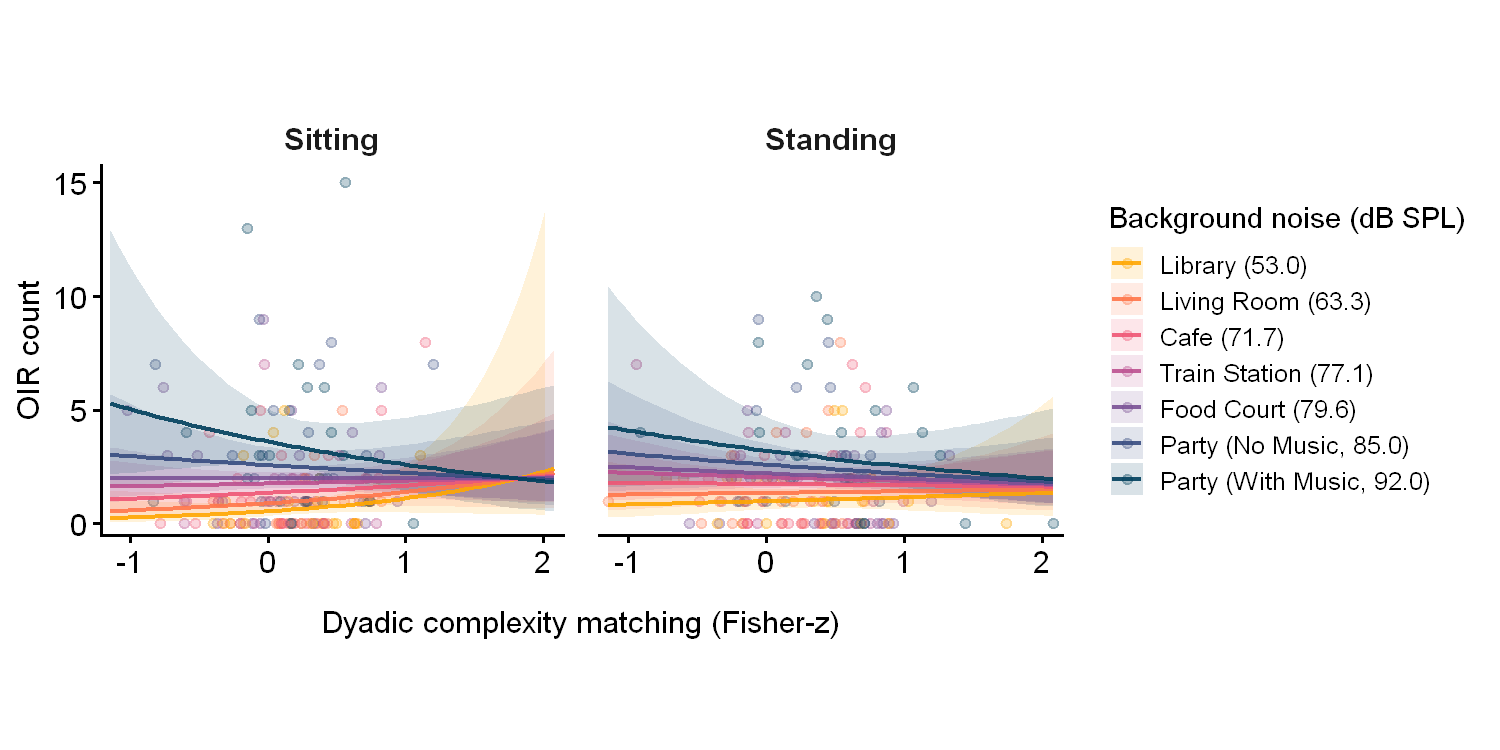

In [55]:
# Filter to actual pairs and dyad correlation type only
cm_oirs_s1 <- cm_df1 %>%
  filter(pair_type == "actual", corr_type == "pair")

# Model
m1_oirs_cm_pair <- glmmTMB(
  oirs ~ alpha_corr_z * condition * environment_cent + (1 | pair),
  family = nbinom2,
  data = cm_oirs_s1
)
summary(m1_oirs_cm_pair)

# Get environment mapping
env_mapping <- cm_oirs_s1 %>%
  group_by(environment, environment_cent) %>%
  summarise(.groups = "drop") %>%
  arrange(environment_cent)

# Create plot using helper function
p_oirs_cm_dyad_s1 <- plot_oirs_by_environment(
  model = m1_oirs_cm_pair,
  data = cm_oirs_s1,
  predictor_cent = "alpha_corr_z",
  predictor_raw = "alpha_corr_z",
  env_mapping = env_mapping,
  has_condition = TRUE,
  xlabel = "Dyadic complexity matching (Fisher-z)",
  ylim_max = 15,
  ybreaks = 5
)

print(p_oirs_cm_dyad_s1)

### 9.2 Study 2: OIRs ~ CM × Environment

 Family: nbinom2  ( log )
Formula:          oirs ~ alpha_corr_z * environment_cent + (1 | pair)
Data: cm_oirs_s2

      AIC       BIC    logLik -2*log(L)  df.resid 
    931.6     952.2    -459.8     919.6       222 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 pair   (Intercept) 0.5059   0.7113  
Number of obs: 228, groups:  pair, 44

Dispersion parameter for nbinom2 family (): 11.2 

Conditional model:
                              Estimate Std. Error z value Pr(>|z|)    
(Intercept)                    0.80714    0.12435   6.491 8.54e-11 ***
alpha_corr_z                  -0.08540    0.24365  -0.350    0.726    
environment_cent               0.08369    0.00425  19.694  < 2e-16 ***
alpha_corr_z:environment_cent -0.00286    0.01896  -0.151    0.880    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

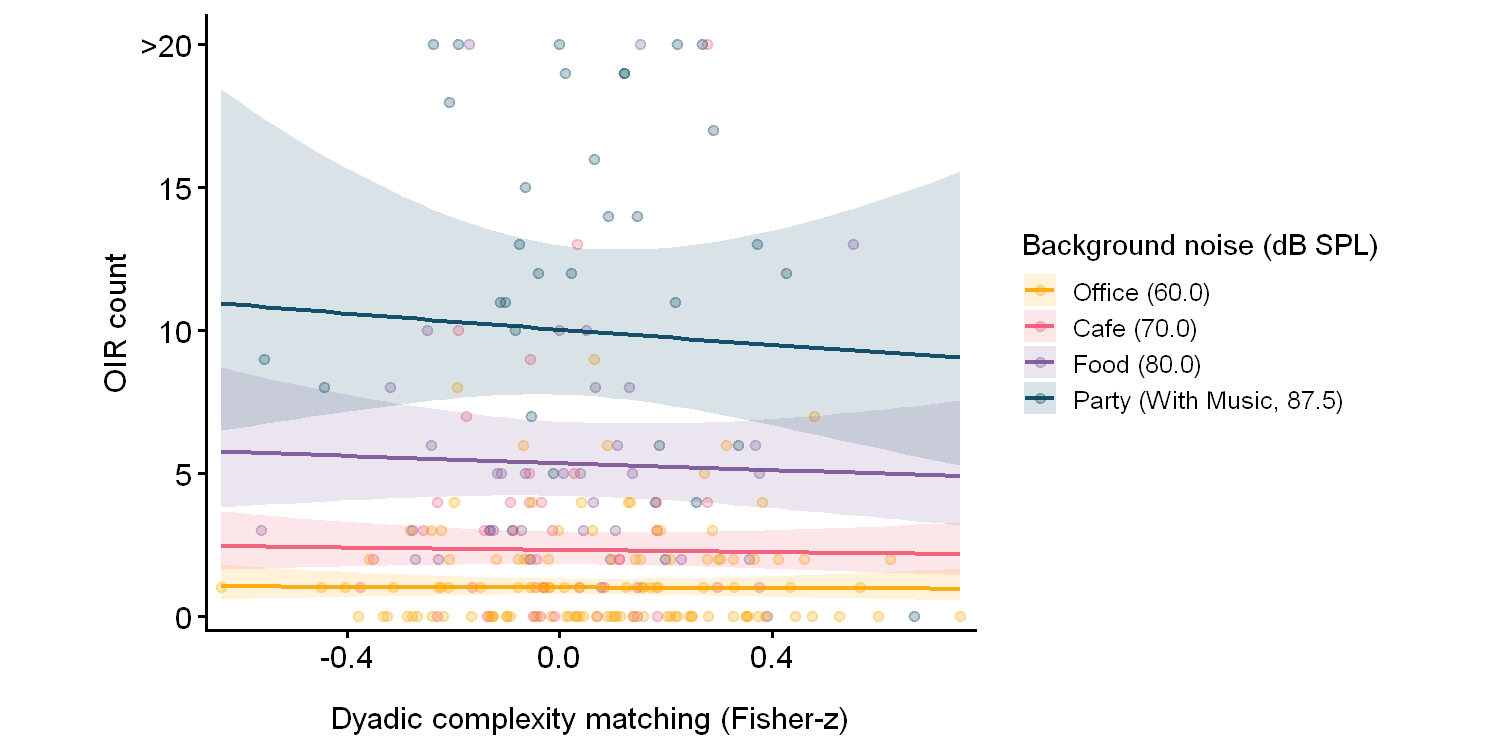

In [56]:
# Filter to actual pairs and dyad correlation type only
cm_oirs_s2 <- cm_df2 %>%
  filter(pair_type == "actual", corr_type == "pair")

# Model
m2_oirs_cm_pair <- glmmTMB(
  oirs ~ alpha_corr_z * environment_cent + (1 | pair),
  family = nbinom2,
  data = cm_oirs_s2
)
summary(m2_oirs_cm_pair)

# Get environment mapping
env_mapping <- cm_oirs_s2 %>%
  group_by(environment, environment_cent) %>%
  summarise(.groups = "drop") %>%
  arrange(environment_cent)

# Generate Study 2 plot via the helper function
p_oirs_cm_dyad_s2 <- plot_oirs_by_environment(
  model        = m2_oirs_cm_pair,
  data         = cm_oirs_s2,
  predictor_cent = "alpha_corr_z",
  predictor_raw  = "alpha_corr_z",
  env_mapping    = env_mapping,
  has_condition  = FALSE,
  xlabel         = "Dyadic complexity matching (Fisher-z)",
  ylim_max = 20,
  ybreaks = 5,
  cap = 20
)

print(p_oirs_cm_dyad_s2)

## 10. RMS Cross Correlation with OIRS

### 10.1 Study 1: OIRs ~ RMS Corr × Condition × Environment

 Family: nbinom2  ( log )
Formula:          oirs ~ rms_corr_z * condition * environment_cent + (1 | pair)
Data: rms_oirs_s1

      AIC       BIC    logLik -2*log(L)  df.resid 
   1140.1    1177.4    -560.1    1120.1       298 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 pair   (Intercept) 0.1662   0.4077  
Number of obs: 308, groups:  pair, 22

Dispersion parameter for nbinom2 family (): 2.48 

Conditional model:
                                               Estimate Std. Error z value
(Intercept)                                    0.422615   0.134465   3.143
rms_corr_z                                     0.181576   0.184813   0.982
conditionstanding                              0.314737   0.144385   2.180
environment_cent                               0.048562   0.008867   5.476
rms_corr_z:conditionstanding                  -0.398139   0.229255  -1.737
rms_corr_z:environment_cent                   -0.019951   0.015456  -1.291
conditionstanding:environm

,condition,rms_corr_z.trend,SE,df,asymp.LCL,asymp.UCL,z.ratio,p.value
,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,sitting,0.1815755,0.1848132,Inf,-0.1806516,0.54380265,0.9824816,0.3258627
2,standing,-0.2165633,0.1375524,Inf,-0.4861610,0.05303431,-1.5744067,0.1153935


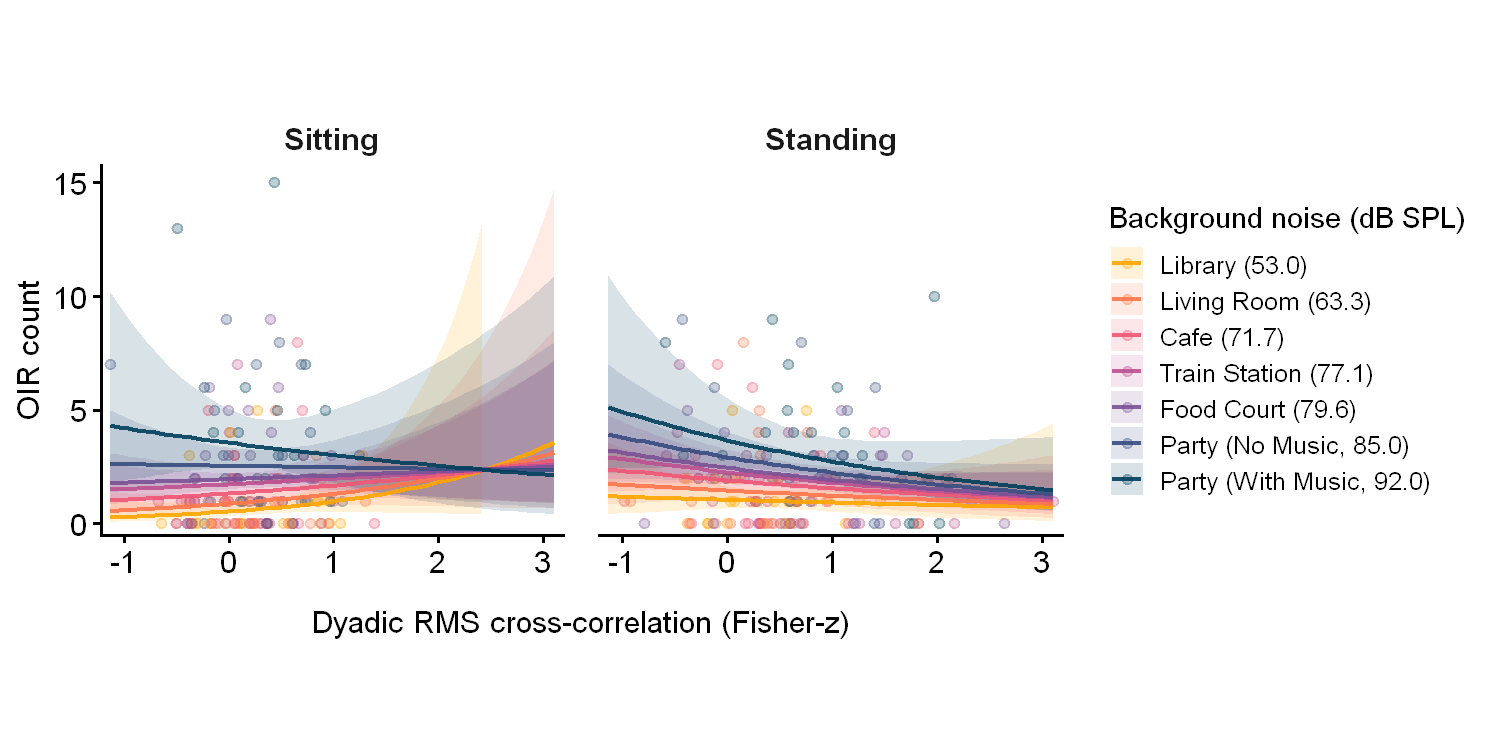

In [57]:
# Filter to actual pairs and dyad correlation type only
rms_oirs_s1 <- cm_df1 %>%
  filter(pair_type == "actual", corr_type == "pair")


# Model (without three-way interaction for convergence)
m1_oirs_rms_pair <- glmmTMB(
  oirs ~ rms_corr_z * condition * environment_cent + (1 | pair),
  family = nbinom2,
  data = rms_oirs_s1
)
summary(m1_oirs_rms_pair)

# Test slopes of rms_corr_z at each condition
slopes_rms_oirs_s1 <- emtrends(
  m1_oirs_rms_pair,
  ~ condition,
  var = "rms_corr_z",
  at = list(condition = unique(rms_oirs_s1$condition)),
  type = "response"
)

# Display slopes with confidence intervals
summary(slopes_rms_oirs_s1, infer = c(TRUE, TRUE))

# Get environment-cent mapping
env_mapping <- rms_oirs_s1 %>%
  group_by(environment, environment_cent) %>%
  summarise(.groups = "drop") %>%
  arrange(environment_cent)

# Use general function
p_oirs_rms_dyad_s1 <- plot_oirs_by_environment(
  model         = m1_oirs_rms_pair,
  data          = rms_oirs_s1,
  predictor_cent = "rms_corr_z",
  predictor_raw  = "rms_corr_z",
  env_mapping    = env_mapping,
  has_condition  = TRUE,  # Study 1
  xlabel         = "Dyadic RMS cross-correlation (Fisher-z)",
  #cap = 15,
  ylim_max = 15,
  ybreaks = 5

)

print(p_oirs_rms_dyad_s1)

### 10.2 Study 2: OIRs ~ RMS Corr × Environment

 Family: nbinom2  ( log )
Formula:          oirs ~ rms_corr_z * environment_cent + (1 | pair)
Data: rms_oirs_s2

      AIC       BIC    logLik -2*log(L)  df.resid 
    924.2     944.8    -456.1     912.2       222 

Random effects:

Conditional model:
 Groups Name        Variance Std.Dev.
 pair   (Intercept) 0.5158   0.7182  
Number of obs: 228, groups:  pair, 44

Dispersion parameter for nbinom2 family (): 16.9 

Conditional model:
                            Estimate Std. Error z value Pr(>|z|)    
(Intercept)                 0.770838   0.125236   6.155  7.5e-10 ***
rms_corr_z                  0.197577   0.174620   1.131   0.2579    
environment_cent            0.080119   0.004068  19.694  < 2e-16 ***
rms_corr_z:environment_cent 0.027263   0.013151   2.073   0.0382 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

,environment_cent,rms_corr_z.trend,SE,df,asymp.LCL,asymp.UCL,z.ratio,p.value
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,-9.5863636,-0.06378084,0.2489134,Inf,-0.5516421,0.4240804,-0.2562371,0.797767754
2,0.4136364,0.20885405,0.1727707,Inf,-0.1297704,0.5474785,1.2088509,0.226720123
3,10.4136364,0.48148895,0.1798040,Inf,0.1290796,0.8338983,2.6778546,0.007409537
4,17.9136364,0.68596512,0.2385112,Inf,0.2184918,1.1534385,2.8760290,0.004027127


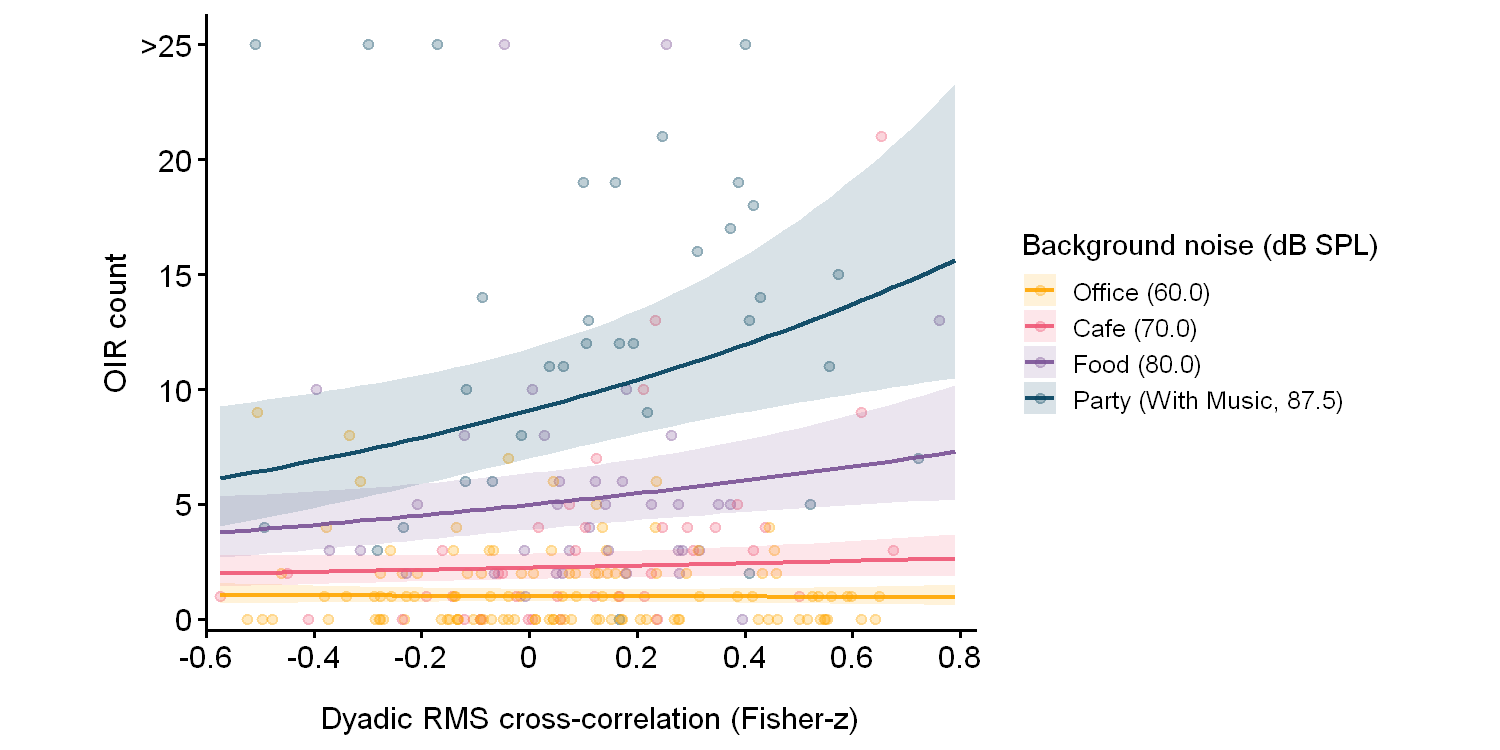

In [58]:
# Filter to actual pairs and dyad correlation type only
rms_oirs_s2 <- cm_df2 %>%
  filter(pair_type == "actual", corr_type == "pair")

# Model
m2_oirs_rms_pair <- glmmTMB(
  oirs ~ rms_corr_z * environment_cent + (1 | pair),
  family = nbinom2,
  data = rms_oirs_s2
)
summary(m2_oirs_rms_pair)

# Get the 7 unique environment_cent values
env_mapping <- rms_oirs_s2 %>%
  group_by(environment, environment_cent) %>%
  summarise(.groups = "drop") %>%
  arrange(environment_cent)

# Test slopes of rms_corr_z at each environment level
slopes_rms_oirs_s2 <- emtrends(
  m2_oirs_rms_pair,
  ~ environment_cent,
  var = "rms_corr_z",
  at = list(environment_cent = env_mapping$environment_cent),
  type = "response"
)

# Display slopes with confidence intervals
summary(slopes_rms_oirs_s2, infer = c(TRUE, TRUE))

# Get environment-cent mapping
env_mapping <- rms_oirs_s2 %>%
  group_by(environment, environment_cent) %>%
  summarise(.groups = "drop") %>%
  arrange(environment_cent)

# Use unified plotting function
p_oirs_rms_dyad_s2 <- plot_oirs_by_environment(
  model         = m2_oirs_rms_pair,
  data          = rms_oirs_s2,
  predictor_cent = "rms_corr_z",
  predictor_raw  = "rms_corr_z",
  env_mapping    = env_mapping,
  has_condition  = FALSE,
  xlabel         = "Dyadic RMS cross-correlation (Fisher-z)",
  output_file    = "figures/manuscript/study2_oirs_by_rms_corr_dyad.png",
  x_limits      = c(-0.60, 0.80),
  ylim_max = 25,
  ybreaks = 5,
  cap = 25
)
print(p_oirs_rms_dyad_s2)